# 다이캐스팅 공정 데이터 분석
> **분석 대상**: Product_Type 1 전용 (Type 2 완전 제외)

> **구성**: 데이터 로드 → 중복 제거 → 결측값 처리 → 이상치 처리 → 타겟/파생변수 → 시각화 → 상관분석 → 모델링

> **이상치 처리 합의 (260303)**
> - Velocity=0 → 삭제
> - Cycle_Time 극단값 → 공정 지연 신호로 유지
> - 절사 기준 IQR / 1% / 0.5% 비교
> - Velocity_2 이상치 184건 → 추가 조사 중

> **SMOTE 미적용** — class_weight로 불균형 대응

In [296]:
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False


## STEP 0. 라이브러리 임포트 및 데이터 로드

In [297]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 데이터 로드 (멀티헤더)
df_raw = pd.read_csv(
    "../../../data/DieCasting_Quality_Raw_Data.csv",
    header=[0, 1]
)
print(f"원본 Shape: {df_raw.shape}")
df_raw.head(3)

원본 Shape: (7535, 57)


Process                                                                   \
       id Product_Type Shot Velocity_1 Velocity_2 Velocity_3 High_Velocity   
0       1            1    1      0.144       0.17      0.188         2.134   
1    1002            1    2      0.144       0.17      0.182         2.124   
2    2003            1    3      0.144       0.17      0.182         2.116   

                                                        ...     Defects  \
  Cylinder_Pressure Rapid_Rise_Time Biscuit_Thickness   ... Blow_Hole_2   
0               214           0.008                 10  ...           0   
1               217           0.008                 11  ...           0   
2               214           0.008                 11  ...           0   

                                                                             \
  Stain_2 Dent_2 Deformation_2 Contamination_2 Impurity_2 Crack_2 Scratch_2   
0       0      0             0               0          0       0         0   
1       0      0             0               0          0       0         0   
2       0      0             0               0          0       0         0   

                              
  Buring_Mark_2 Inclusions_2  
0             0            0  
1             0            0  
2             0            0  

[3 rows x 57 columns]

## STEP 1. 데이터 구조 파악

In [298]:
print("컬럼 그룹:", df_raw.columns.get_level_values(0).unique().tolist())
print(f"전체 컬럼 수: {len(df_raw.columns)}")
df_raw.info()

컬럼 그룹: ['Process', 'Sensor', 'Defects']
전체 컬럼 수: 57
<class 'pandas.DataFrame'>
RangeIndex: 7535 entries, 0 to 7534
Data columns (total 57 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   (Process, id)                   7535 non-null   int64  
 1   (Process, Product_Type)         7535 non-null   int64  
 2   (Process, Shot)                 7535 non-null   int64  
 3   (Process, Velocity_1)           7535 non-null   float64
 4   (Process, Velocity_2)           7535 non-null   float64
 5   (Process, Velocity_3)           7535 non-null   float64
 6   (Process, High_Velocity)        7535 non-null   float64
 7   (Process, Cylinder_Pressure)    7535 non-null   int64  
 8   (Process, Rapid_Rise_Time)      7535 non-null   float64
 9   (Process, Biscuit_Thickness )   7535 non-null   int64  
 10  (Process, Clamping_Force )      7535 non-null   int64  
 11  (Process, Cycle_Time)           7535 non-null   float6

In [299]:
df_raw.describe()

Process                                                      \
                 id Product_Type         Shot   Velocity_1   Velocity_2   
count  7.535000e+03  7535.000000  7535.000000  7535.000000  7535.000000   
mean   3.767454e+06     1.441672   453.798938     0.148219     0.168801   
std    2.175264e+06     0.496619   319.451698     0.007134     0.004720   
min    1.000000e+00     1.000000     0.000000     0.134000     0.158000   
25%    1.883893e+06     1.000000   195.000000     0.142000     0.166000   
50%    3.767193e+06     1.000000   401.000000     0.144000     0.168000   
75%    5.650924e+06     2.000000   645.000000     0.156000     0.170000   
max    7.534661e+06     2.000000  1296.000000     0.180000     0.212000   

                                                                    \
        Velocity_3 High_Velocity Cylinder_Pressure Rapid_Rise_Time   
count  7535.000000   7535.000000       7535.000000     7535.000000   
mean      0.191193      2.319210        239.655607        0.009596   
std       0.011563      0.222041         23.305451        0.002148   
min       0.172000      0.000000        107.000000        0.000000   
25%       0.181000      2.134000        217.000000        0.008000   
50%       0.188000      2.161000        239.000000        0.009000   
75%       0.202000      2.523000        265.000000        0.012000   
max       0.234000      2.744000        266.000000        0.021000   

                          ...      Defects                                     \
      Biscuit_Thickness   ...  Blow_Hole_2 Stain_2       Dent_2 Deformation_2   
count        7535.000000  ...  7535.000000  7535.0  7535.000000   7535.000000   
mean           14.309622  ...     0.021367     0.0     0.000531      0.008626   
std             3.286284  ...     0.150020     0.0     0.023036      0.093907   
min             0.000000  ...     0.000000     0.0     0.000000      0.000000   
25%            11.000000  ...     0.000000     0.0     0.000000      0.000000   
50%            13.000000  ...     0.000000     0.0     0.000000      0.000000   
75%            17.000000  ...     0.000000     0.0     0.000000      0.000000   
max            24.000000  ...     2.000000     0.0     1.000000      2.000000   

                                                                         \
      Contamination_2   Impurity_2      Crack_2 Scratch_2 Buring_Mark_2   
count     7535.000000  7535.000000  7535.000000    7535.0        7535.0   
mean         0.001062     0.000664     0.000265       0.0           0.0   
std          0.032569     0.025753     0.016291       0.0           0.0   
min          0.000000     0.000000     0.000000       0.0           0.0   
25%          0.000000     0.000000     0.000000       0.0           0.0   
50%          0.000000     0.000000     0.000000       0.0           0.0   
75%          0.000000     0.000000     0.000000       0.0           0.0   
max          1.000000     1.000000     1.000000       0.0           0.0   

                    
      Inclusions_2  
count  7535.000000  
mean      0.000133  
std       0.011520  
min       0.000000  
25%       0.000000  
50%       0.000000  
75%       0.000000  
max       1.000000  

[8 rows x 57 columns]

In [300]:
df_raw.nunique()

Process  id                      7535
         Product_Type               2
         Shot                    1271
         Velocity_1                33
         Velocity_2                27
         Velocity_3                45
         High_Velocity            319
         Cylinder_Pressure         22
         Rapid_Rise_Time           18
         Biscuit_Thickness         24
         Clamping_Force            42
         Cycle_Time                61
          Pressure_Rise_Time       16
         Casting_Pressure          65
         Spray_Time                32
         Spray_1_Time               7
         Spray_2_Time               8
Sensor   Melting_Furnace_Temp     737
         Air_Pressure              26
         Air_Pressure_Min           1
         Air_Pressure_Max           1
         Coolant_Temp              23
         Coolant_Temp_Min           1
         Coolant_Temp_Max           1
         Coolant_Pressure          22
         Factory_Temp              67
         Fac

In [301]:
# 전체 중복 데이터 확인(id 컬럼 포함)
df_raw.duplicated().sum()

np.int64(0)

In [302]:
# 고유 id 제외 중복 확인(id 컬럼 제외)
df_dropid = df_raw.drop(columns=[('Process','id')]).copy()
df_dropid.duplicated().sum()

np.int64(2918)

1 Shot = 2 데이터 발생  
5836/2918 == 2 -> 정확히 1 Shot에 대해 같은 데이터 한 쌍이 생성됨(불량 데이터 포함)

In [303]:
# id 컬럼을 제외한 데이터 중, 중복 데이터만 모아서 확인
duplicate_rows = df_dropid[df_dropid.duplicated(keep=False)]

duplicate_rows

Process                                                      \
     Product_Type Shot Velocity_1 Velocity_2 Velocity_3 High_Velocity   
1099            1    1      0.140      0.168      0.182         2.153   
1100            1    1      0.140      0.168      0.182         2.153   
1101            1    2      0.142      0.170      0.180         2.157   
1102            1    2      0.142      0.170      0.180         2.157   
1103            1    3      0.142      0.170      0.180         2.157   
...           ...  ...        ...        ...        ...           ...   
7530            2  659      0.150      0.166      0.210         2.492   
7531            2  660      0.144      0.174      0.206         2.514   
7532            2  660      0.144      0.174      0.206         2.514   
7533            2  661      0.147      0.174      0.204         2.532   
7534            2  661      0.147      0.174      0.204         2.532   

                                                                           \
     Cylinder_Pressure Rapid_Rise_Time Biscuit_Thickness  Clamping_Force    
1099               218           0.009                 10             255   
1100               218           0.009                 10             255   
1101               218           0.008                 11             257   
1102               218           0.008                 11             257   
1103               218           0.008                 11             257   
...                ...             ...                ...             ...   
7530               265           0.011                 17             381   
7531               264           0.011                 16             381   
7532               264           0.011                 16             381   
7533               265           0.012                 18             382   
7534               265           0.012                 18             382   

      ...     Defects                                                          \
      ... Blow_Hole_2 Stain_2 Dent_2 Deformation_2 Contamination_2 Impurity_2   
1099  ...           0       0      0             0               0          0   
1100  ...           0       0      0             0               0          0   
1101  ...           0       0      0             0               0          0   
1102  ...           0       0      0             0               0          0   
1103  ...           0       0      0             0               0          0   
...   ...         ...     ...    ...           ...             ...        ...   
7530  ...           0       0      0             0               0          0   
7531  ...           0       0      0             0               0          0   
7532  ...           0       0      0             0               0          0   
7533  ...           0       0      0             0               0          0   
7534  ...           0       0      0             0               0          0   

                                                   
     Crack_2 Scratch_2 Buring_Mark_2 Inclusions_2  
1099       0         0             0            0  
1100       0         0             0            0  
1101       0         0             0            0  
1102       0         0             0            0  
1103       0         0             0            0  
...      ...       ...           ...          ...  
7530       0         0             0            0  
7531       0         0             0            0  
7532       0         0             0            0  
7533       0         0             0            0  
7534       0         0             0            0  

[5836 rows x 56 columns]

중복 데이터 5836건 중, 불량 정보까지 정확히 일치하는 데이터 1232건 발견

In [304]:
# 중복 데이터 중 불량 데이터만 확인
duplicate_defects = duplicate_rows[duplicate_rows['Defects'].sum(axis=1)>0]
# Shot 별 확인을 위해 Shot을 기준으로 정렬
sorted_dup_def = duplicate_defects.sort_values(by=('Process','Shot'))

# Shot 인덱스화
sorted_dup_def.index = duplicate_defects['Process']['Shot']
sorted_dup_def.index.name = 'Shot'
sorted_dup_def['Defects']

,Short_Shot_1,Bubble_1,Exfoliation_1,Blow_Hole_1,Stain_1,Dent_1,Deformation_1,Contamination_1,Impurity_1,Crack_1,...,Blow_Hole_2,Stain_2,Dent_2,Deformation_2,Contamination_2,Impurity_2,Crack_2,Scratch_2,Buring_Mark_2,Inclusions_2
Shot,,,,,,,,,,,,,,,,,,,,,
3,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
650,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
660,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
660,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


중복 데이터 5836건 중, 불량이 전혀 없는 양품 데이터 4604건 발견

In [305]:
# 중복 데이터 중 양품 데이터만 확인
duplicate_good = duplicate_rows[duplicate_rows['Defects'].sum(axis=1)==0]
# Shot 별 확인을 위해 Shot을 기준으로 정렬
sorted_dup_good = duplicate_good.sort_values(by=('Process','Shot'))

# Shot 인덱스화
sorted_dup_good.index = duplicate_good['Process']['Shot']
sorted_dup_good.index.name = 'Shot'
sorted_dup_good['Defects']

,Short_Shot_1,Bubble_1,Exfoliation_1,Blow_Hole_1,Stain_1,Dent_1,Deformation_1,Contamination_1,Impurity_1,Crack_1,...,Blow_Hole_2,Stain_2,Dent_2,Deformation_2,Contamination_2,Impurity_2,Crack_2,Scratch_2,Buring_Mark_2,Inclusions_2
Shot,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
657,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
658,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
658,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [306]:
display(duplicate_rows.sort_values(by=('Process','Shot')).head(30))

Process                                                      \
     Product_Type Shot Velocity_1 Velocity_2 Velocity_3 High_Velocity   
4807            2    0      0.156      0.170      0.208         2.533   
4808            2    0      0.156      0.170      0.208         2.533   
1099            1    1      0.140      0.168      0.182         2.153   
1100            1    1      0.140      0.168      0.182         2.153   
4809            2    1      0.156      0.170      0.208         2.533   
4810            2    1      0.156      0.170      0.208         2.533   
1101            1    2      0.142      0.170      0.180         2.157   
1102            1    2      0.142      0.170      0.180         2.157   
4811            2    2      0.149      0.174      0.204         2.506   
4812            2    2      0.149      0.174      0.204         2.506   
4813            2    3      0.144      0.164      0.203         2.529   
4814            2    3      0.144      0.164      0.203         2.529   
1103            1    3      0.142      0.170      0.180         2.157   
1104            1    3      0.142      0.170      0.180         2.157   
4816            2    4      0.158      0.160      0.204         2.506   
4815            2    4      0.158      0.160      0.204         2.506   
1105            1    4      0.144      0.170      0.182         2.097   
1106            1    4      0.144      0.170      0.182         2.097   
3414            1    5      0.139      0.168      0.186         1.295   
3413            1    5      0.139      0.168      0.186         1.295   
6265            2    5      0.154      0.168      0.196         2.544   
6266            2    5      0.154      0.168      0.196         2.544   
4817            2    5      0.158      0.164      0.204         2.499   
4818            2    5      0.158      0.164      0.204         2.499   
1108            1    5      0.144      0.170      0.182         2.097   
1107            1    5      0.144      0.170      0.182         2.097   
6268            2    6      0.150      0.174      0.200         2.533   
4819            2    6      0.160      0.170      0.212         2.519   
6267            2    6      0.150      0.174      0.200         2.533   
4820            2    6      0.160      0.170      0.212         2.519   

                                                                           \
     Cylinder_Pressure Rapid_Rise_Time Biscuit_Thickness  Clamping_Force    
4807               265           0.012                 16             355   
4808               265           0.012                 16             355   
1099               218           0.009                 10             255   
1100               218           0.009                 10             255   
4809               265           0.012                 16             355   
4810               265           0.012                 16             355   
1101               218           0.008                 11             257   
1102               218           0.008                 11             257   
4811               264           0.012                 16             357   
4812               264           0.012                 16             357   
4813               264           0.012                 13             361   
4814               264           0.012                 13             361   
1103               218           0.008                 11             257   
1104               218           0.008                 11             257   
4816               265           0.012                 15             361   
4815               265           0.012                 15             361   
1105               218           0.009                 10             259   
1106               218           0.009                 10             259   
3414               216           0.008                 12             258   
3413               216           0.008                 1

In [307]:
duplicate_rows[[('Process', 'Product_Type'),('Process', 'Shot')]].value_counts().head(30)

(Process, Product_Type)  (Process, Shot)
2                        44                 6
                         45                 6
                         46                 6
                         47                 6
1                        5                  4
                         6                  4
                         7                  4
                         10                 4
                         11                 4
                         12                 4
                         13                 4
                         14                 4
                         15                 4
                         16                 4
                         17                 4
                         18                 4
                         19                 4
                         20                 4
                         21                 4
                         22                 4
                         23            

모든 Product Type에 대해 Shot값이 중복되어 기입될 수 있다는 것을 확인

In [308]:
type_shot_df = df_raw[[('Process','Product_Type','Process','Shot')]]
type_shot_df.duplicated(keep=False).sum()

np.int64(7535)

In [309]:
type_shot_df.value_counts()

(Process, Product_Type)
1                          4207
2                          3328
Name: count, dtype: int64

In [310]:
df_raw['Process', 'id'].value_counts()

(Process, id)
1          1
1002       1
2003       1
3004       1
4005       1
          ..
7530659    1
7531660    1
7532660    1
7533661    1
7534661    1
Name: count, Length: 7535, dtype: int64

In [311]:
missing_cnt = df_raw.isnull().sum()
missing_cols = missing_cnt[missing_cnt > 0]

display(missing_cols.sort_values(ascending=False))

Sensor  Factory_Temp            90
        Factory_Temp_Min        90
        Factory_Temp_Max        90
        Factory_Humidity        90
        Factory_Humidity_Min    90
        Factory_Humidity_Max    90
dtype: int64

In [312]:
mis_df = pd.DataFrame({
    'missing_cnt': missing_cols,
    'missing_pct': df_raw[missing_cols.index].isnull().mean() * 100
})

mis_df.sort_values('missing_cnt', ascending=False)

missing_cnt  missing_pct
Sensor Factory_Temp                   90     1.194426
       Factory_Temp_Min               90     1.194426
       Factory_Temp_Max               90     1.194426
       Factory_Humidity               90     1.194426
       Factory_Humidity_Min           90     1.194426
       Factory_Humidity_Max           90     1.194426

In [313]:
shot_cnt = df_raw['Process','Shot'].value_counts()
print(shot_cnt)

(Process, Shot)
44     12
45     12
46     12
47     12
11     10
       ..
973     1
974     1
975     1
976     1
977     1
Name: count, Length: 1271, dtype: int64


In [314]:
df_raw['Process', 'Shot'].nunique()

1271

- Shot이 고유값이 아님을 확인.

In [315]:
df_process = df_raw['Process'].copy()
df_sensor = df_raw['Sensor'].copy()
df_defects = df_raw['Defects'].copy()

df_process.set_index('id',inplace=True)

df_sensor.index = df_raw['Process']['id']
df_sensor.index.name = 'id'
df_defects.index = df_raw['Process']['id']
df_defects.index.name = 'id'

 **분포 확인**

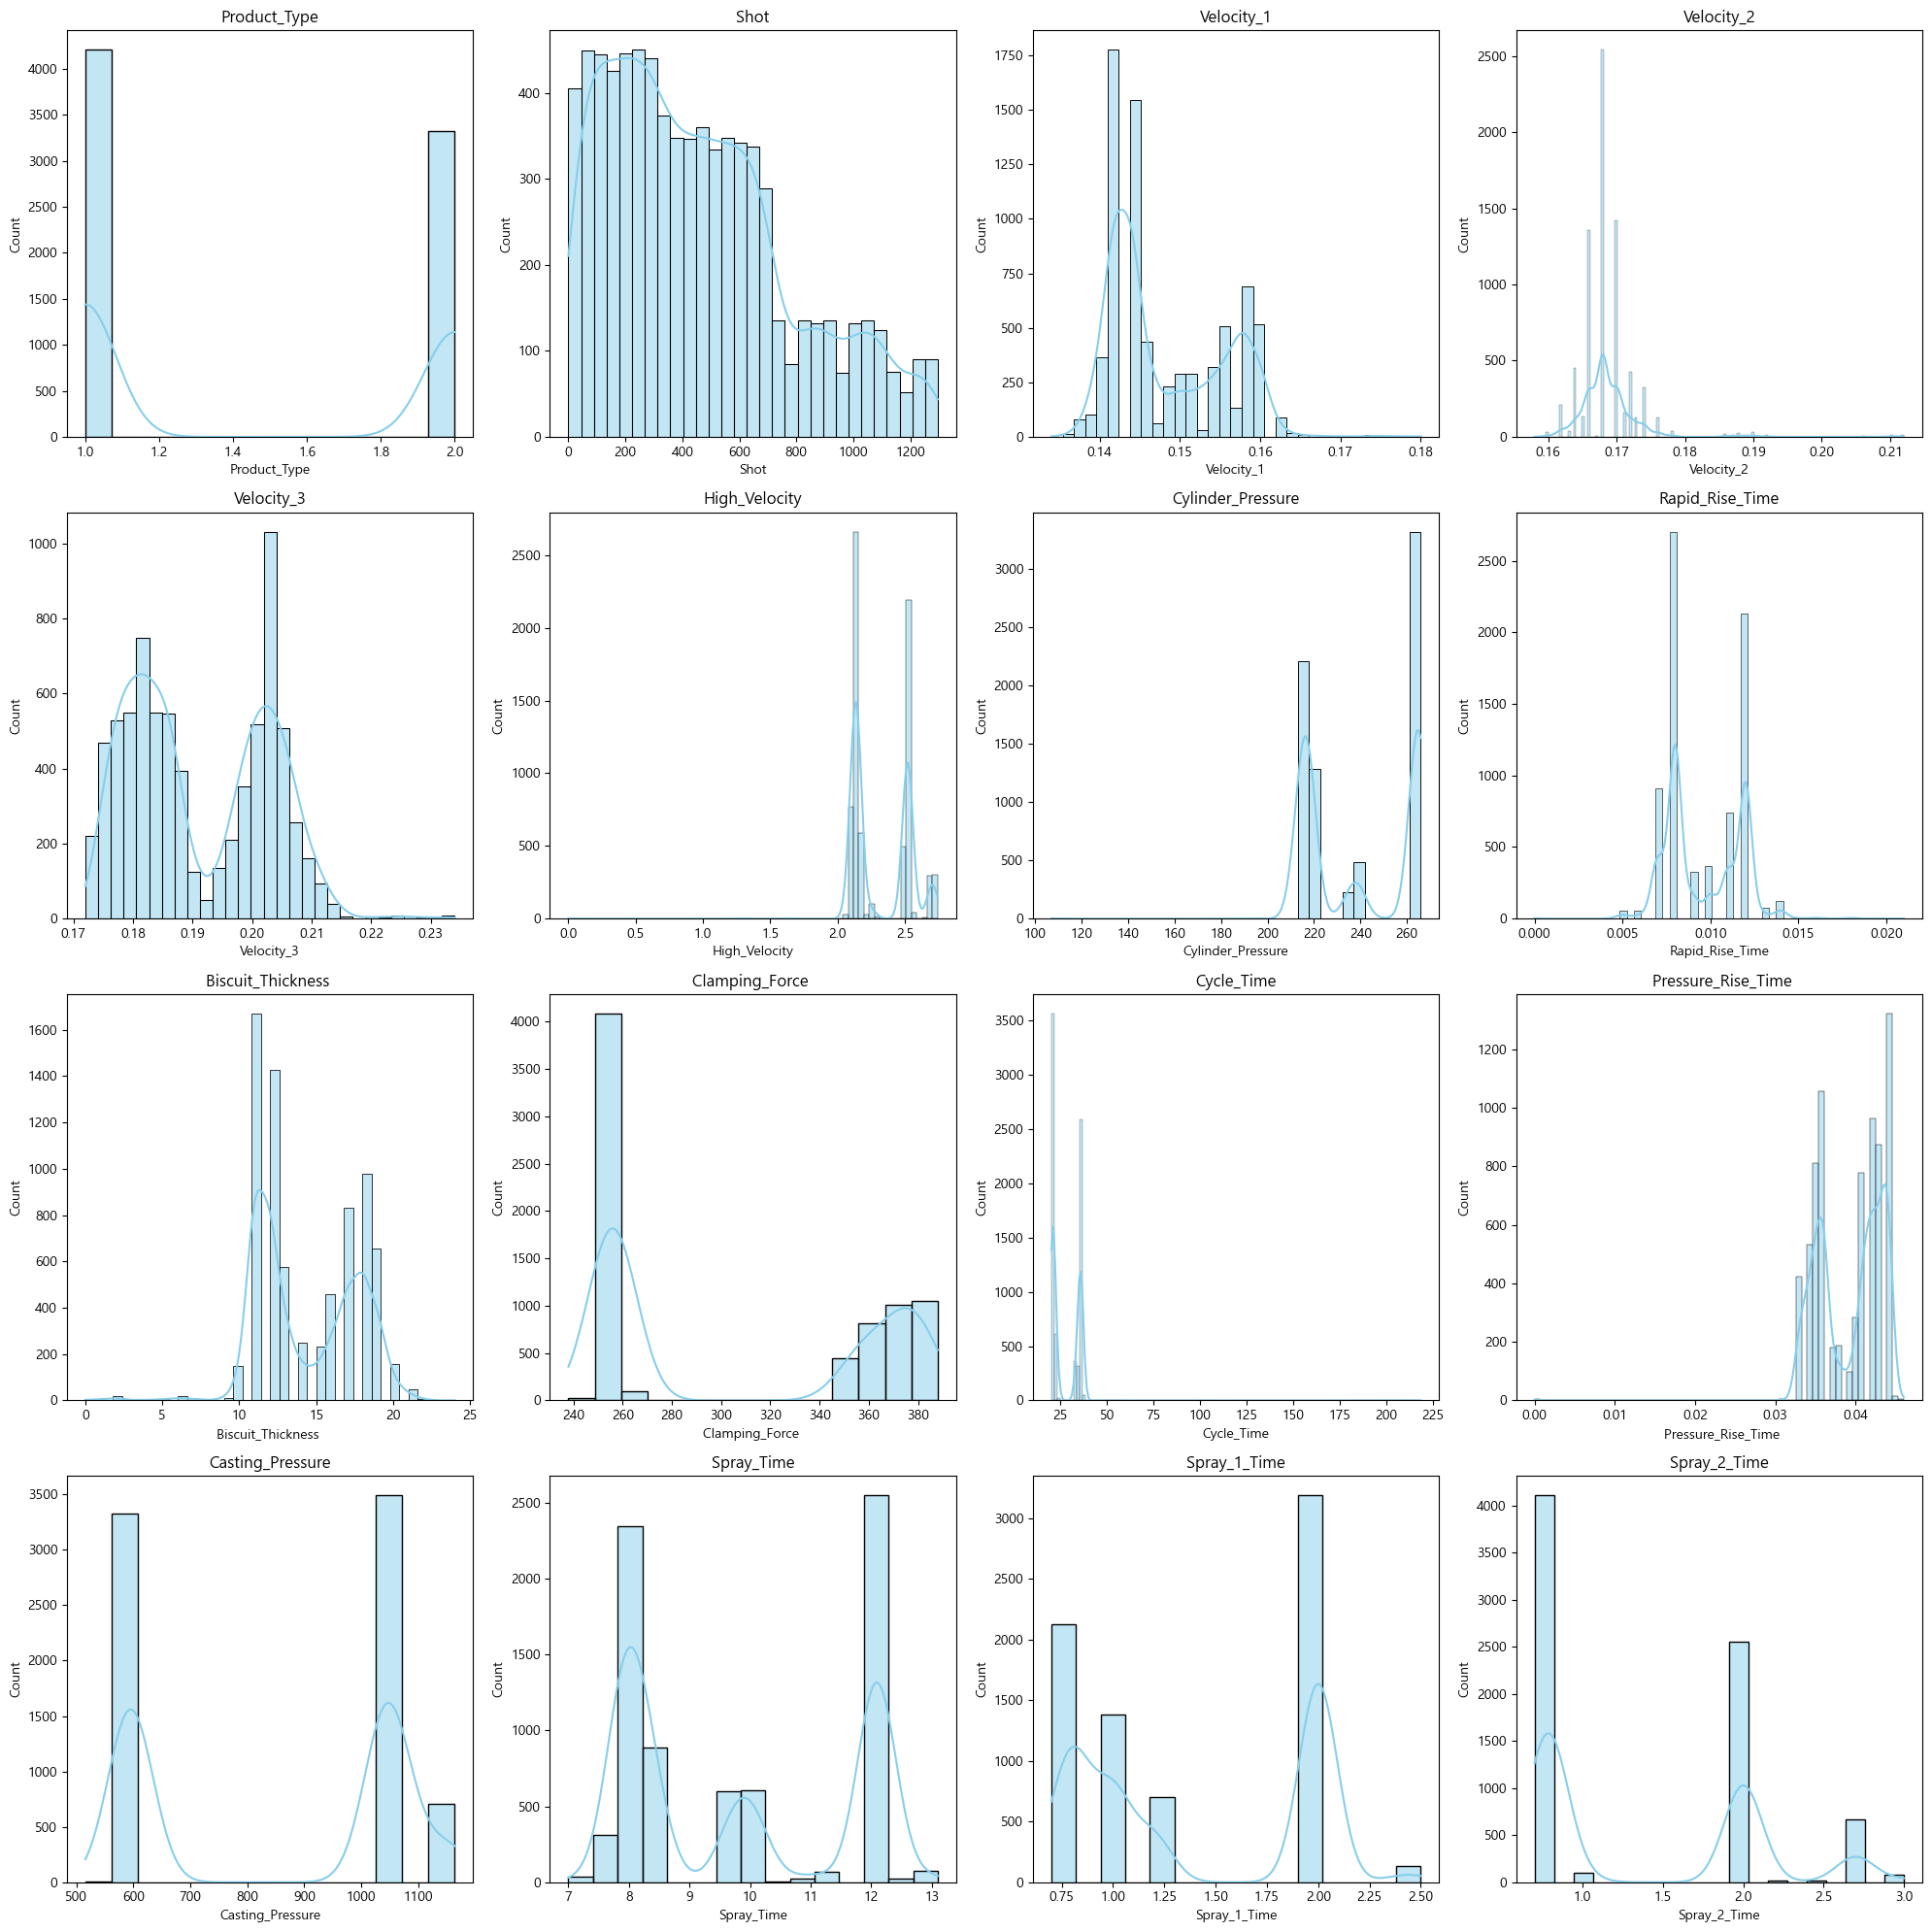

In [316]:
# df_process의 컬럼 목록
cols = df_process.columns
num_cols = len(cols)

# 한 줄에 4개씩 그래프를 그리도록 설정
n_cols = 4 
n_rows = (num_cols + n_cols - 1) // n_cols 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten() # 1차원 배열로 풀어서 반복문에 사용하기 쉽게 함

# 각 컬럼별로 히스토그램 그리기
for i, col in enumerate(cols):
    sns.histplot(df_process[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(col)

# 혹시 남는 빈 축(빈 그래프 공간)이 있다면 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

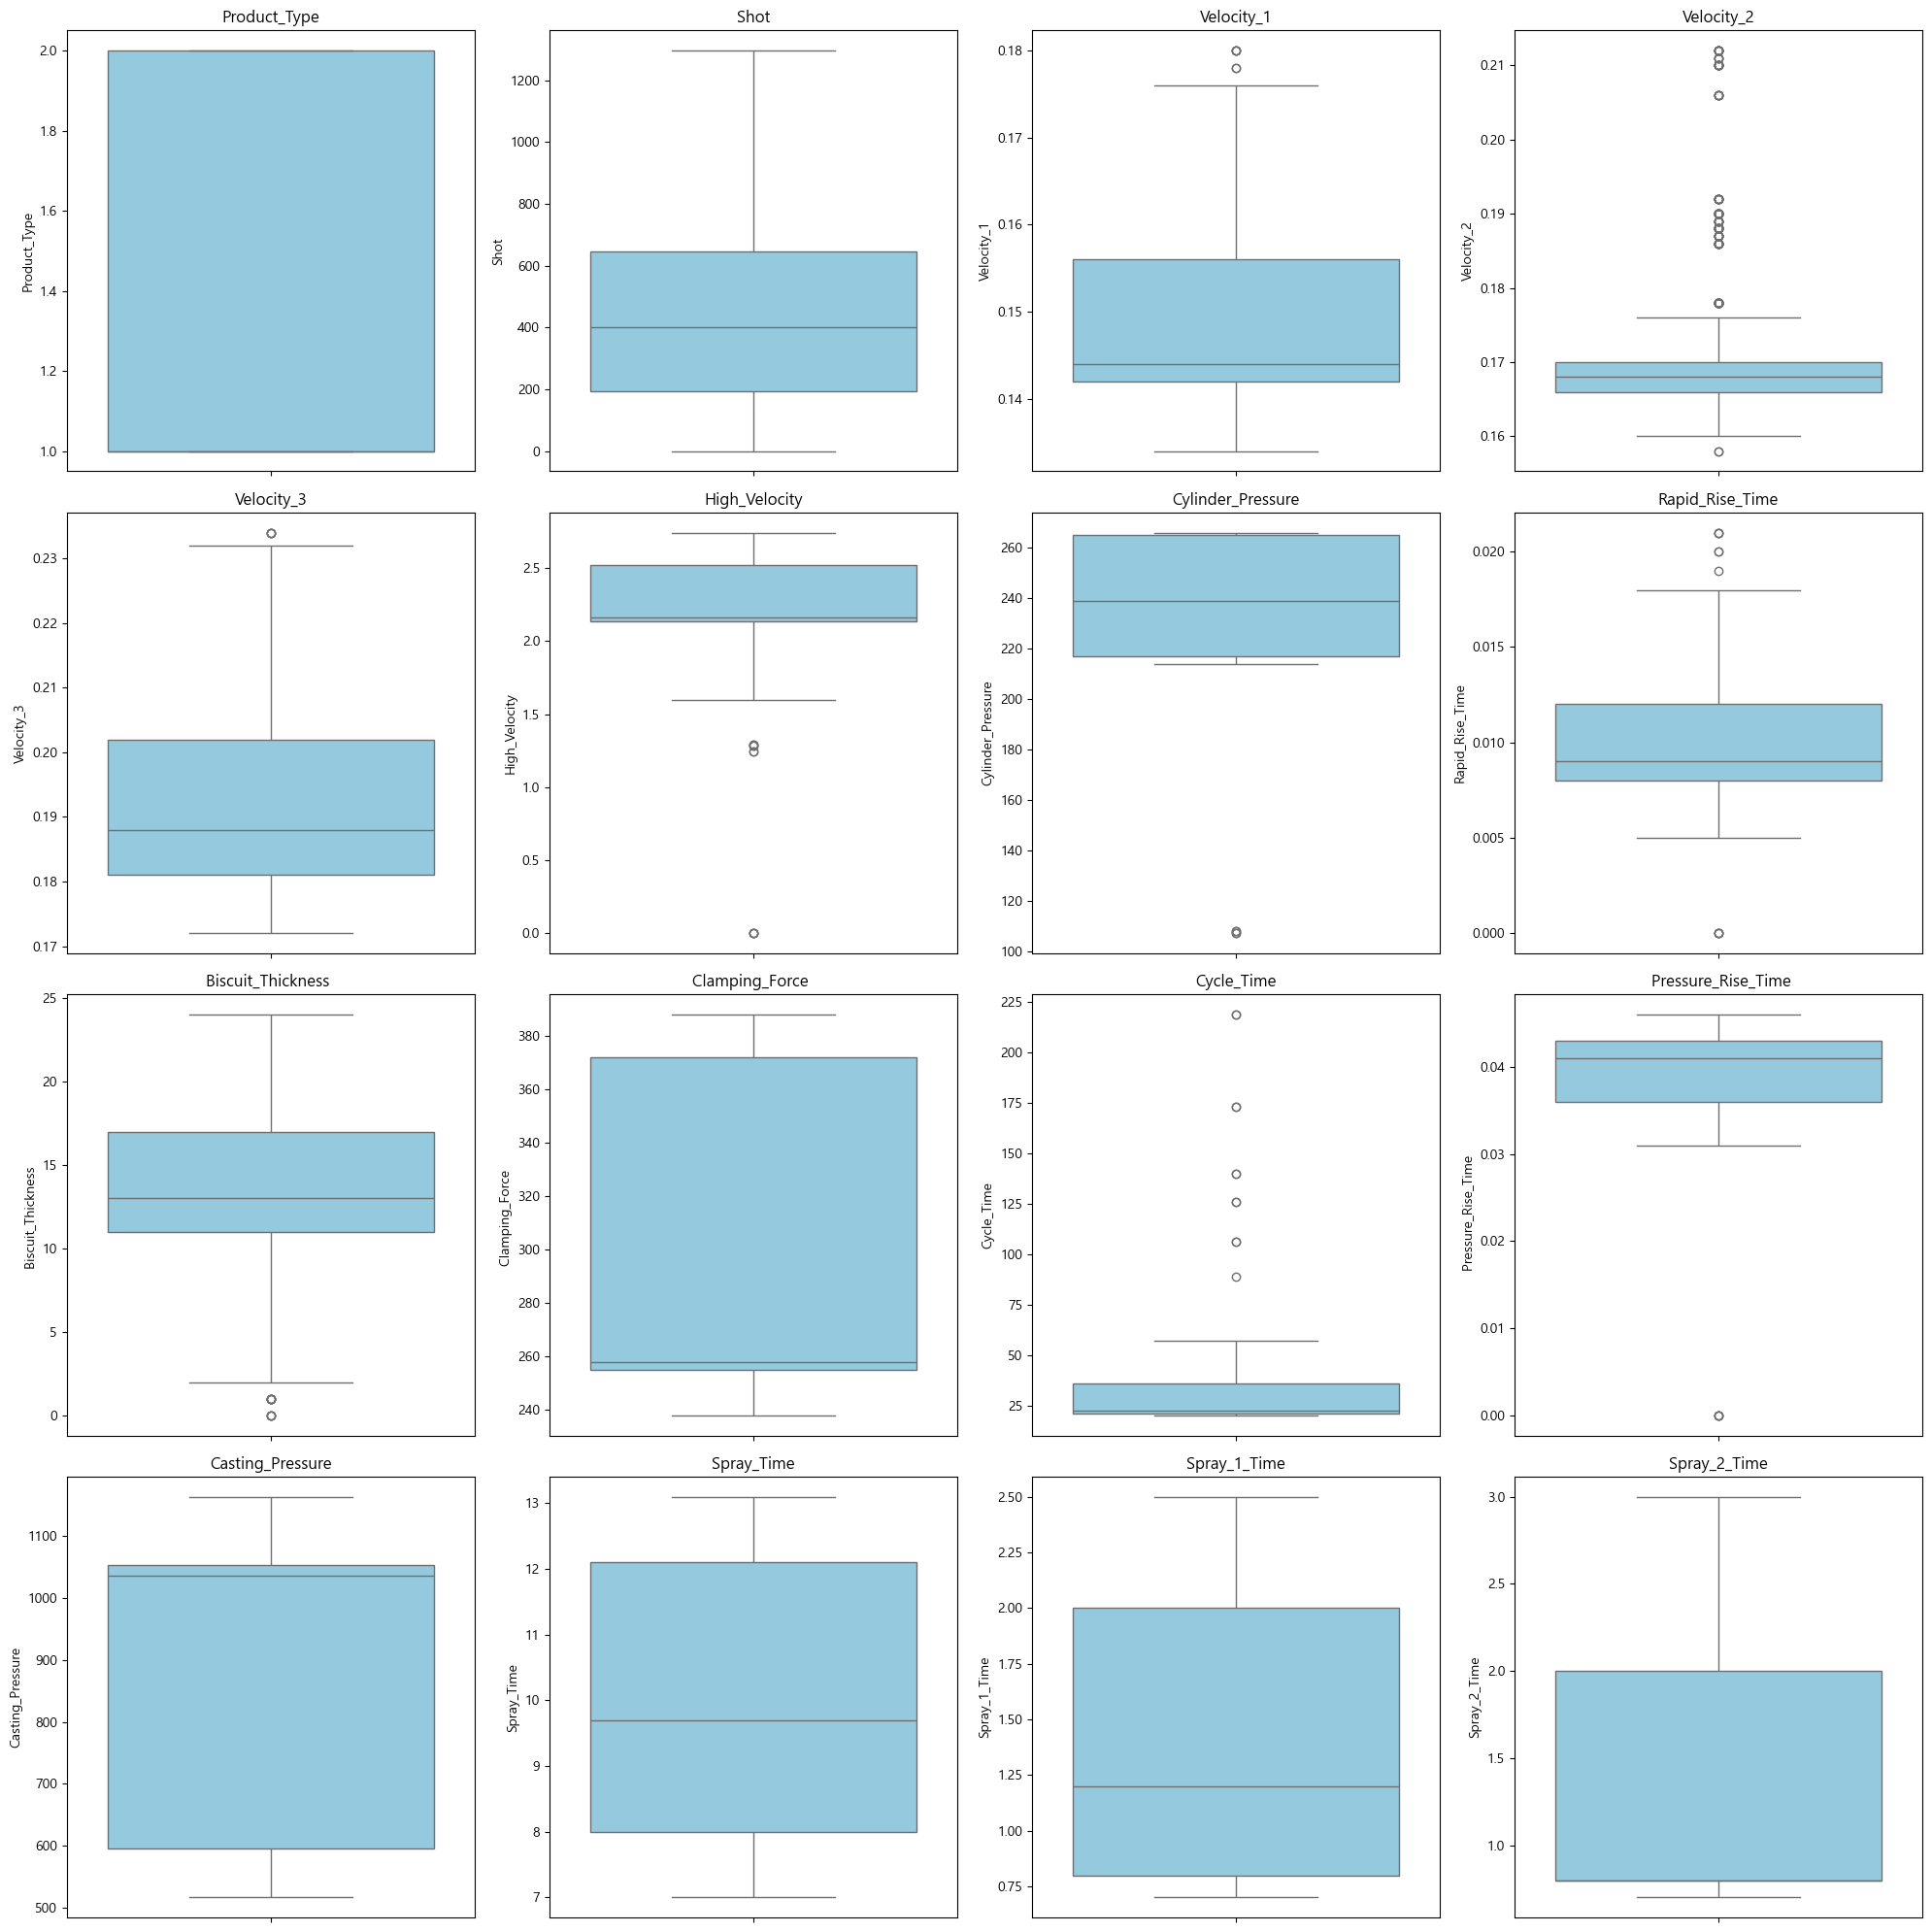

In [317]:
# df_process의 컬럼 목록
cols = df_process.columns
num_cols = len(cols)

# 한 줄에 4개씩 그래프를 그리도록 설정
n_cols = 4 
# math.ceil(num_cols / n_cols) 대신 아래 식을 사용합니다.
n_rows = (num_cols + n_cols - 1) // n_cols 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

# 각 컬럼별로 박스플롯 그리기
for i, col in enumerate(cols):
    sns.boxplot(y=df_process[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col)

# 혹시 남는 빈 축(빈 그래프 공간)이 있다면 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### 전처리 전 Product_Type 별 process 컬럼 분포

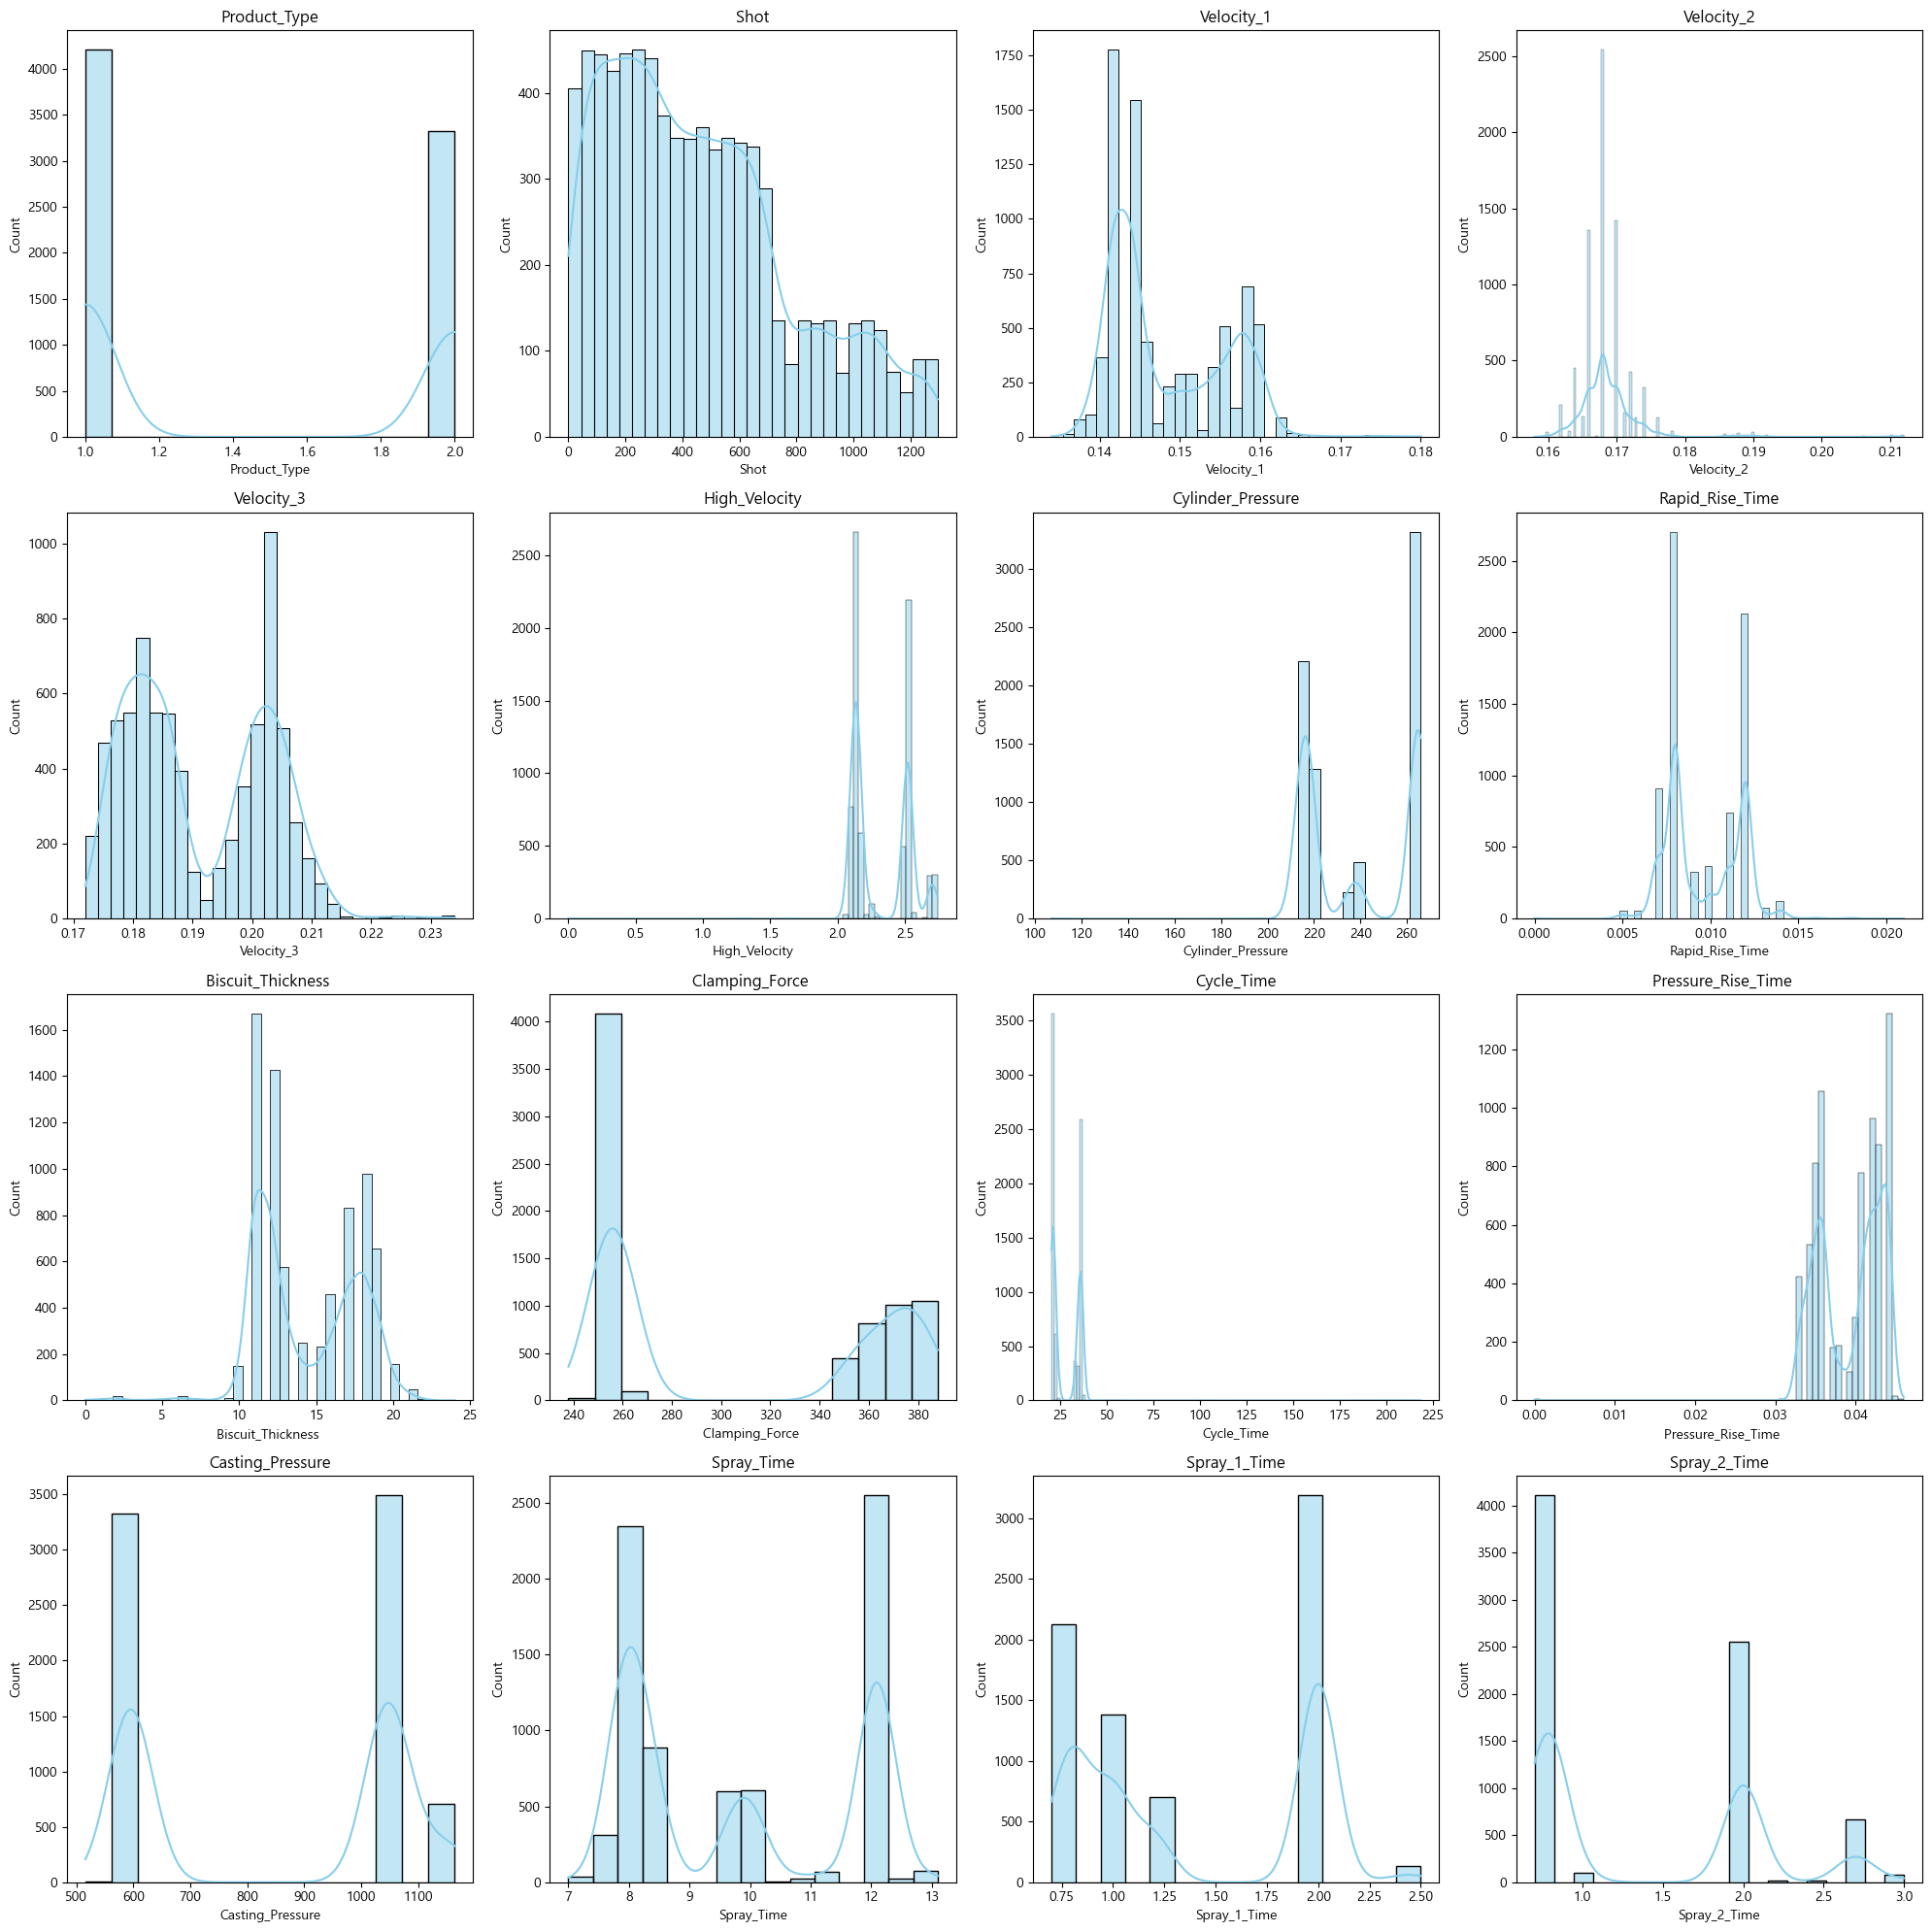

In [318]:
# df_process의 컬럼 목록
cols = df_process.columns
num_cols = len(cols)

# 한 줄에 4개씩 그래프를 그리도록 설정
n_cols = 4 
n_rows = (num_cols + n_cols - 1) // n_cols 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten() # 1차원 배열로 풀어서 반복문에 사용하기 쉽게 함

# 각 컬럼별로 히스토그램 그리기
for i, col in enumerate(cols):
    sns.histplot(df_process[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(col)

# 혹시 남는 빈 축(빈 그래프 공간)이 있다면 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

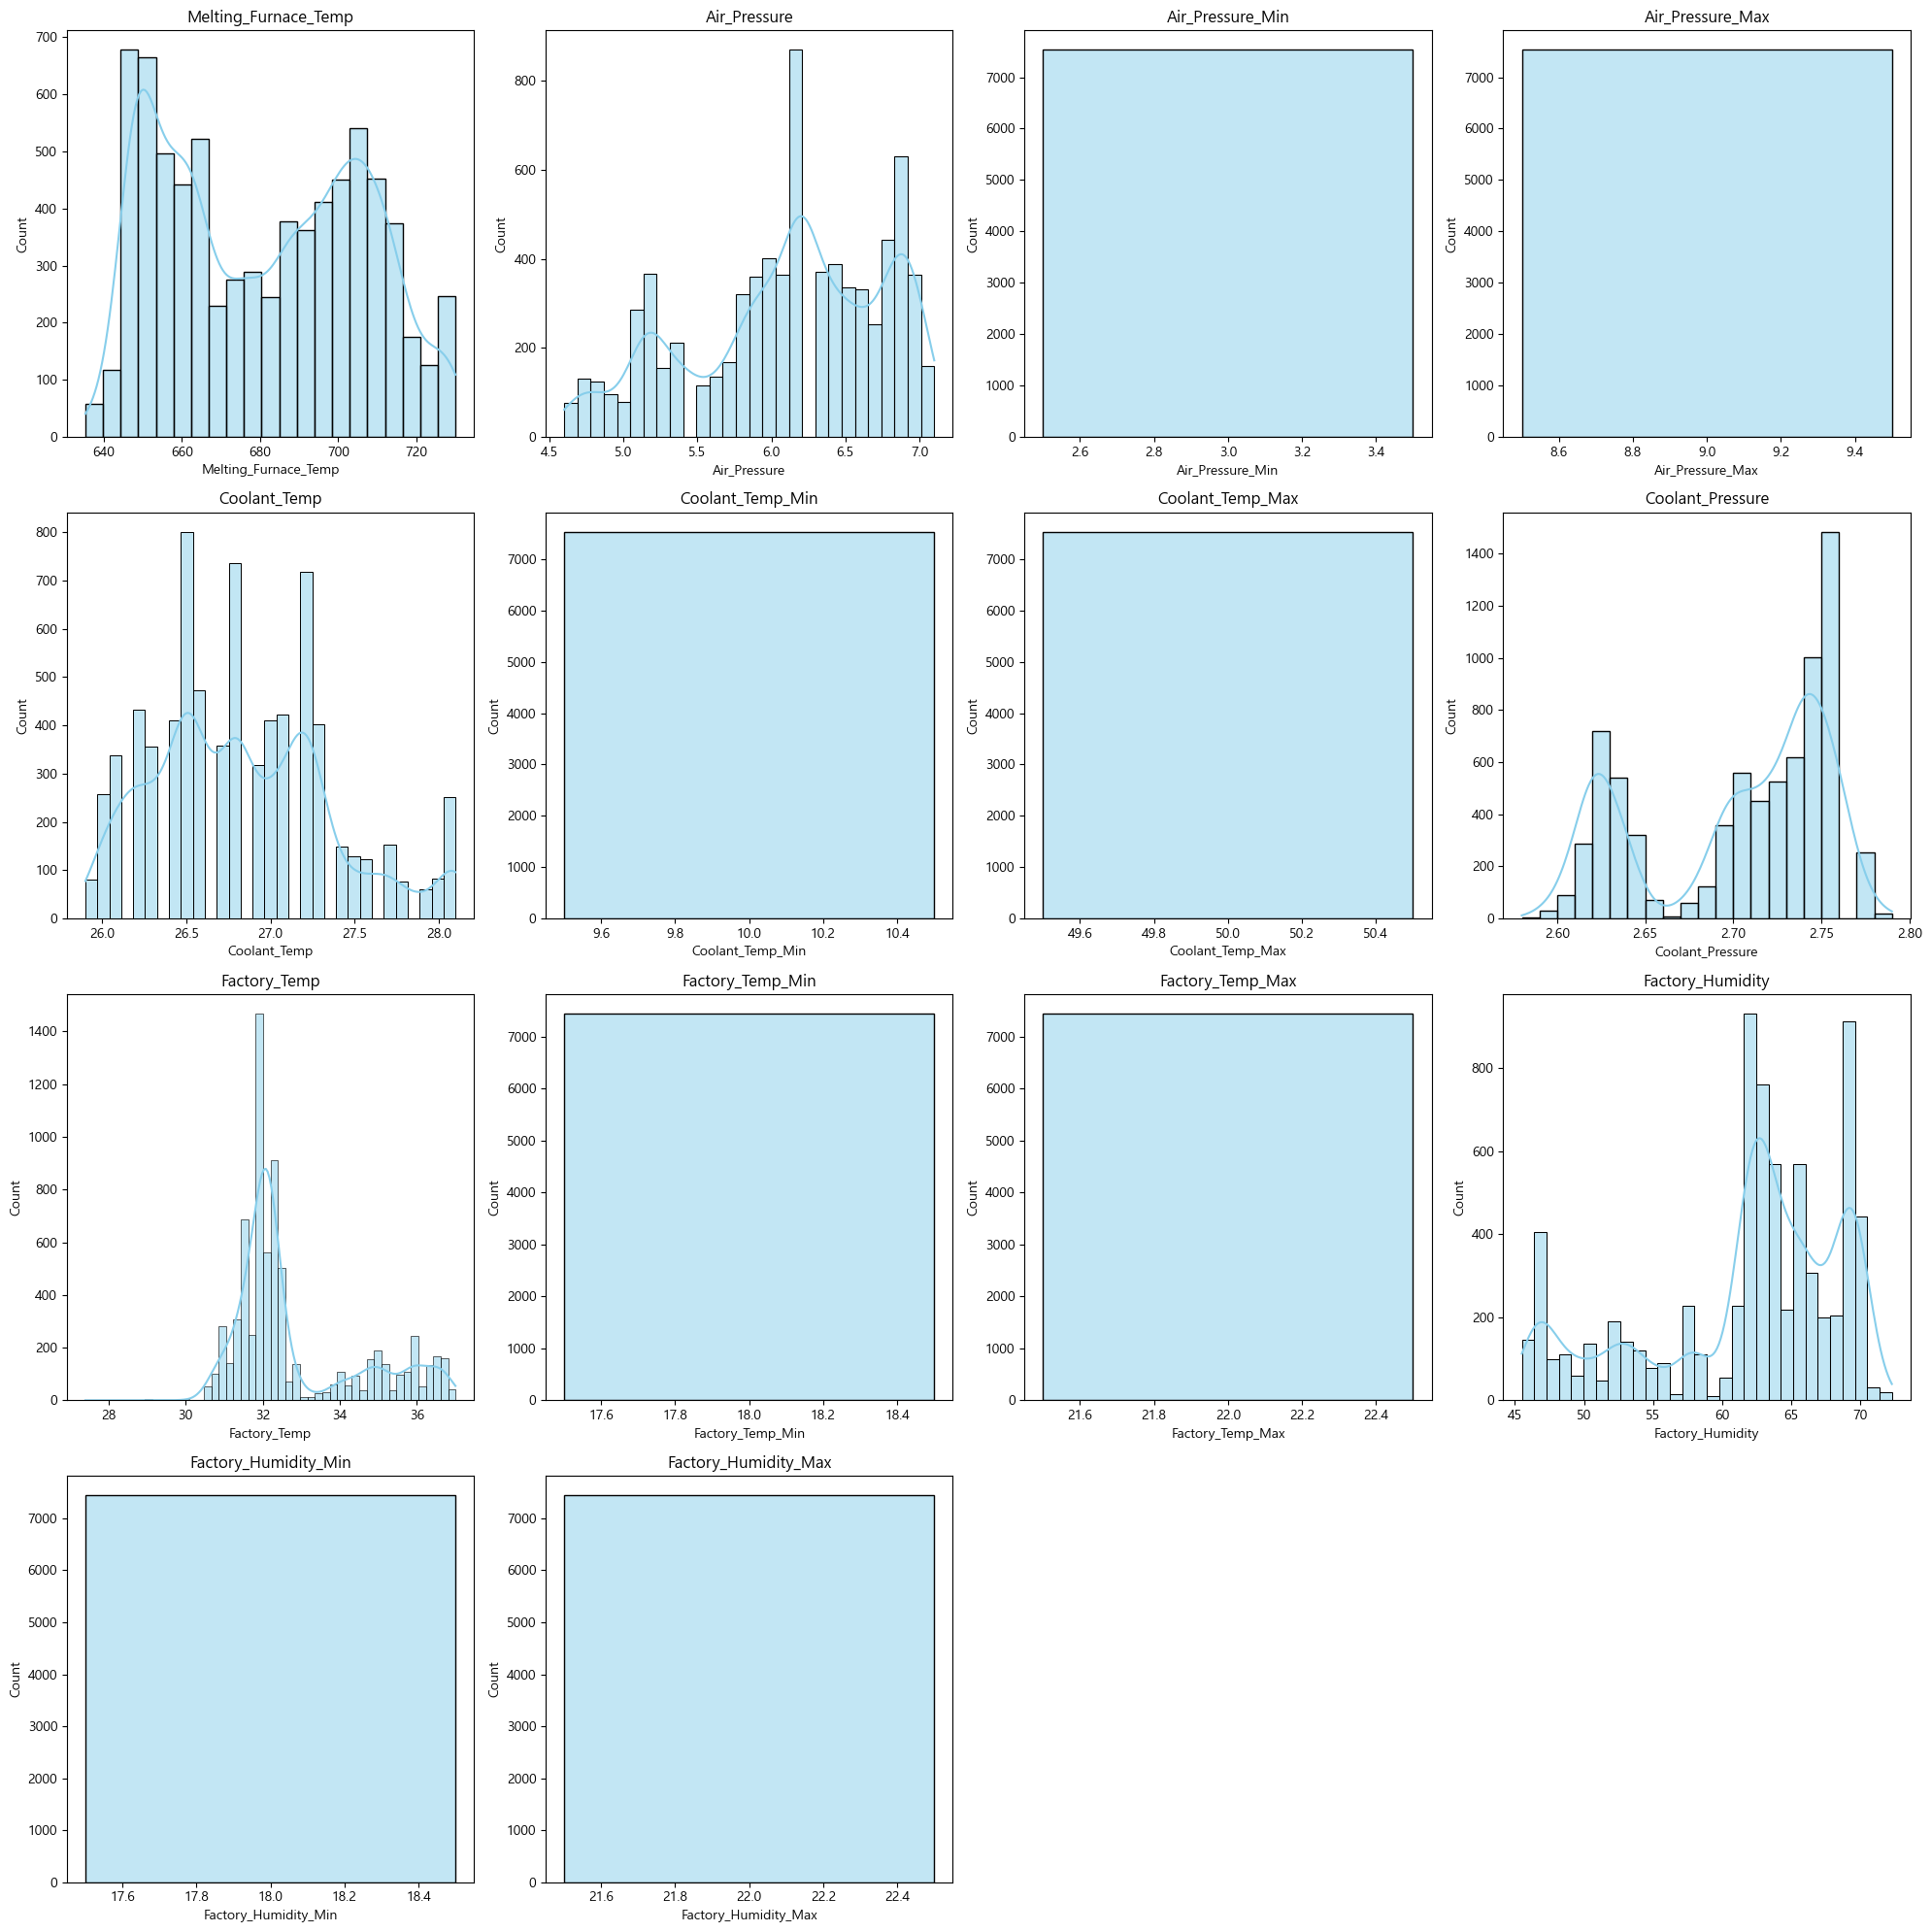

In [319]:
# df_sensor의 컬럼 목록
cols = df_sensor.columns
num_cols = len(cols)

# 한 줄에 4개씩 그래프를 그리도록 설정
n_cols = 4 
# math.ceil(num_cols / n_cols) 대신 아래 식을 사용합니다.
n_rows = (num_cols + n_cols - 1) // n_cols 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten() # 1차원 배열로 풀어서 반복문에 사용하기 쉽게 함

# 각 컬럼별로 히스토그램 그리기
for i, col in enumerate(cols):
    sns.histplot(df_sensor[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(col)

# 혹시 남는 빈 축(빈 그래프 공간)이 있다면 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

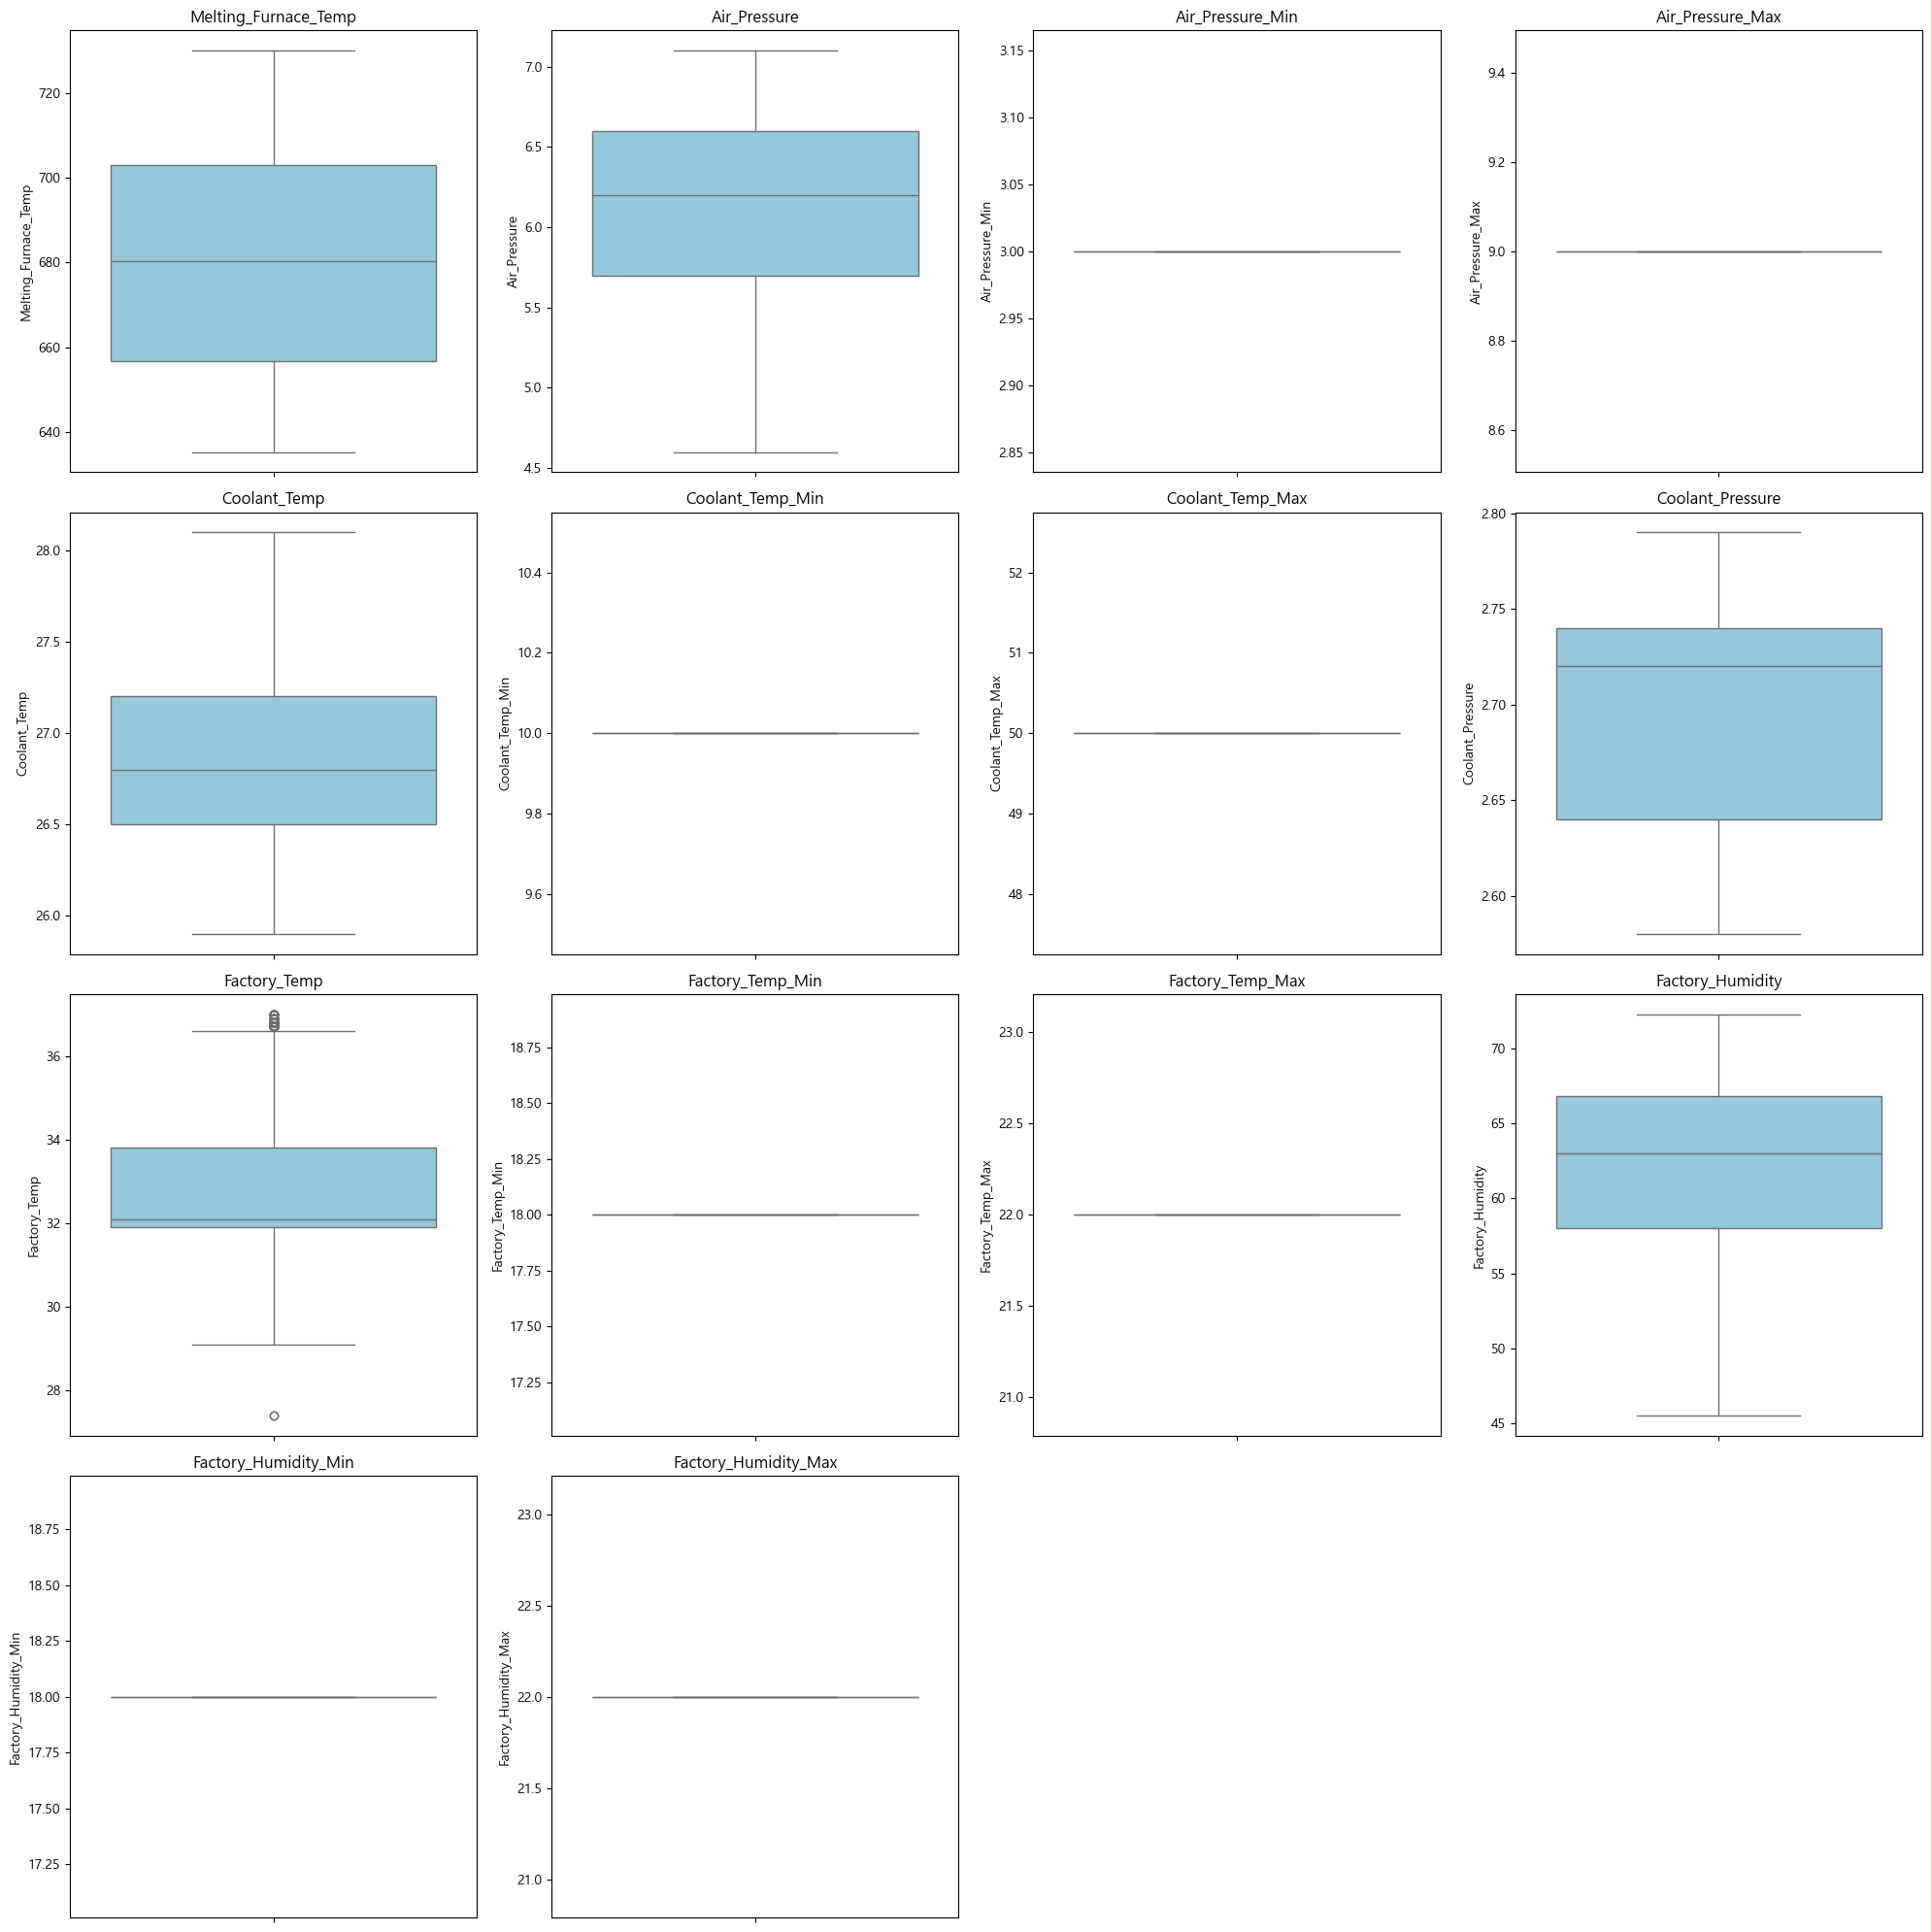

In [320]:
# df_sensor의 컬럼 목록
cols = df_sensor.columns
num_cols = len(cols)

# 한 줄에 4개씩 그래프를 그리도록 설정
n_cols = 4 
# math.ceil(num_cols / n_cols) 대신 아래 식을 사용합니다.
n_rows = (num_cols + n_cols - 1) // n_cols 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

# 각 컬럼별로 박스플롯 그리기
for i, col in enumerate(cols):
    sns.boxplot(y=df_sensor[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col)

# 혹시 남는 빈 축(빈 그래프 공간)이 있다면 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

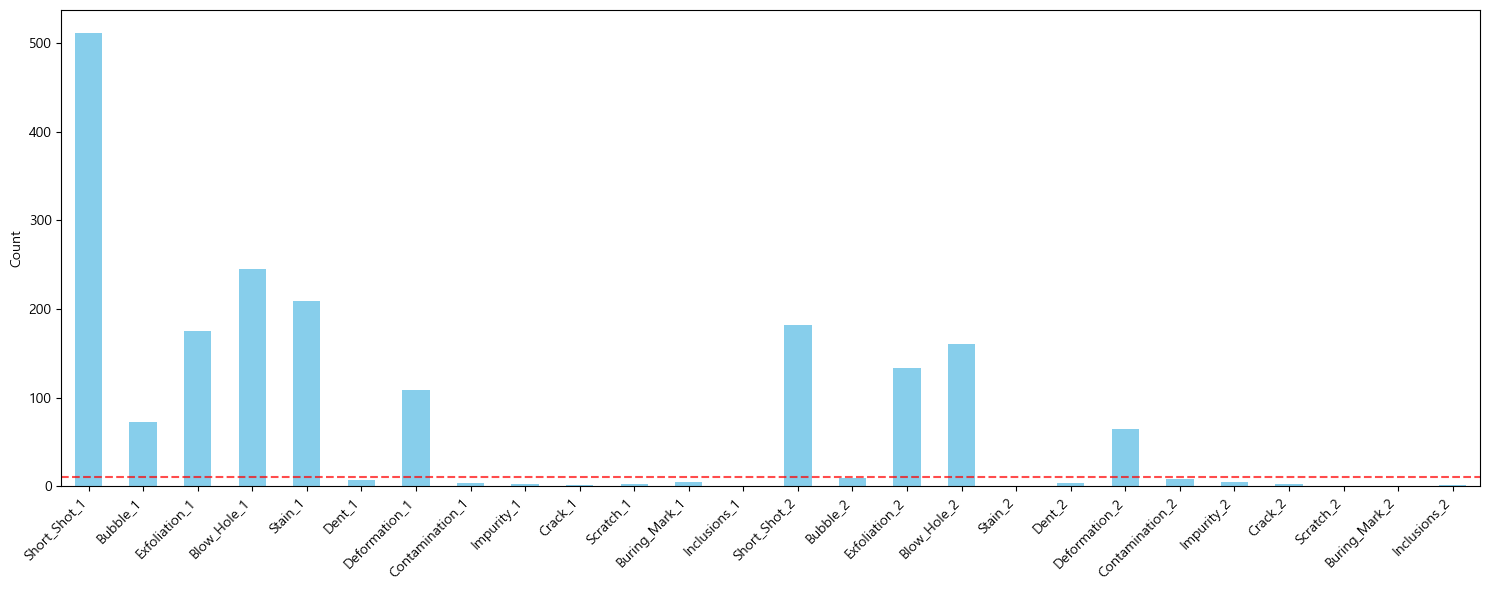

In [321]:
defect_counts = df_defects.sum()

plt.figure(figsize=(15, 6))

defect_counts.plot(kind='bar', color='skyblue')
plt.axhline(y=10, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## STEP 2. 헤더 정리
> 멀티헤더 → 단일헤더 변환 

In [322]:
df = df_raw.copy()

# 멀티헤더 → 단일헤더
df.columns = df.columns.get_level_values(1).str.strip()

# 수치형 변환
df.iloc[:, 1:] = df.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')

 ## STEP3. 중복 데이터 삭제
 > id 제외 기준 완전 중복 행 탐지 후 제거

> **판단 근거**: Cavity 정보는 이미 _1/_2 컬럼으로 하나의 행에 통합되어 있어
> 완전 중복 행은 데이터 수집 오기로 판단

In [323]:
print(f"중복 제거 전: {df.shape[0]}행")
print(f"id 제외 중복 행 수: {df.drop(columns=['id']).duplicated().sum()}건")

# 중복 중 불량/양품 분포 확인
defect_cols_check = [c for c in df.columns if any(c.startswith(d) for d in [
    'Short_Shot','Bubble','Exfoliation','Blow_Hole','Stain','Dent',
    'Deformation','Contamination','Impurity','Crack','Scratch','Buring_Mark','Inclusions'
])]
dup_mask = df.drop(columns=['id']).duplicated(keep=False)
dup_rows = df[dup_mask]
print(f"중복 행 중 불량: {(dup_rows[defect_cols_check].sum(axis=1)>0).sum()}건")
print(f"중복 행 중 양품: {(dup_rows[defect_cols_check].sum(axis=1)==0).sum()}건")

중복 제거 전: 7535행
id 제외 중복 행 수: 2918건
중복 행 중 불량: 1232건
중복 행 중 양품: 4604건


In [324]:
# 중복 제거 (첫 번째 행 유지)
before = df.shape[0]
dedup_cols = [c for c in df.columns if c != 'id']
df = df.drop_duplicates(subset=dedup_cols, keep='first').reset_index(drop=True)

print(f"✅ 중복 제거 완료")
print(f"   제거 전: {before}행 → 제거 후: {df.shape[0]}행 (제거: {before - df.shape[0]}건)")

✅ 중복 제거 완료
   제거 전: 7535행 → 제거 후: 4617행 (제거: 2918건)


## STEP 4.이상치 처리 
> 도메인 특성을 바탕으로 불량 탐지모델을 목표로 하기 때문에 최소한의 처리만 하기로 결정 

In [325]:
# 이상치 탐지 함수(iqr)

def detect_outliers_iqr(dataframe, cols):
    outlier_info = {}
    for col in cols:
        Q1, Q3 = dataframe[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower, upper = Q1 - 3.0*IQR, Q3 + 3.0*IQR
        mask = (dataframe[col] < lower) | (dataframe[col] > upper)
        outlier_info[col] = {
            'count': mask.sum(),
            'pct(%)': f"{mask.mean()*100:.2f}",
            'lower_bound': round(lower, 3),
            'upper_bound': round(upper, 3)
        }
    result = pd.DataFrame(outlier_info).T.sort_values('count', ascending=False)
    return result[result['count'] > 0]

process_num_cols = [
    'Velocity_1','Velocity_2','Velocity_3','High_Velocity',
    'Cylinder_Pressure','Rapid_Rise_Time','Biscuit_Thickness',
    'Clamping_Force','Cycle_Time','Pressure_Rise_Time',
    'Casting_Pressure','Spray_Time','Spray_1_Time','Spray_2_Time'
]

# ── 분산=0 또는 IQR=0 변수 사전 확인 → Capping 대상에서 제외
zero_var_cols = []
for col in process_num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    if df[col].std() == 0 or df[col].nunique() <= 1 or IQR == 0:
        zero_var_cols.append(col)

if zero_var_cols:
    print(f"⚠️  IQR=0 또는 분산=0 변수 발견 → Capping 대상 제외: {zero_var_cols}")
    for col in zero_var_cols:
        print(f"   {col}: 고유값={df[col].nunique()}, IQR={df[col].quantile(0.75)-df[col].quantile(0.25):.4f}")
else:
    print("✅ 분산=0 / IQR=0 변수 없음")

# Capping 가능한 컬럼만 추출 (IQR=0 + Cycle_Time 제외)
cap_cols = [c for c in process_num_cols if c != 'Cycle_Time' and c not in zero_var_cols]
print(f"\nCapping 대상 컬럼 ({len(cap_cols)}개): {cap_cols}")

print("\n[ Process 변수 이상치 탐지 (IQR=0 제외) ]")
display(detect_outliers_iqr(df, cap_cols))
print("\n※ Cycle_Time → Capping 제외 (공정 지연 신호 유지)")
print("※ Velocity_2 이상치 → 추가 조사 중 (현재 IQR Capping 유지)")
if zero_var_cols:
    print(f"※ {zero_var_cols} → IQR=0으로 Capping 제외 (이후 피처에서도 제거)")

✅ 분산=0 / IQR=0 변수 없음

Capping 대상 컬럼 (13개): ['Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity', 'Cylinder_Pressure', 'Rapid_Rise_Time', 'Biscuit_Thickness', 'Clamping_Force', 'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time', 'Spray_1_Time', 'Spray_2_Time']

[ Process 변수 이상치 탐지 (IQR=0 제외) ]


,count,pct(%),lower_bound,upper_bound
Velocity_2,72,1.56,0.154,0.182
High_Velocity,2,0.04,0.964,3.694
Pressure_Rise_Time,2,0.04,0.015,0.064



※ Cycle_Time → Capping 제외 (공정 지연 신호 유지)
※ Velocity_2 이상치 → 추가 조사 중 (현재 IQR Capping 유지)


In [326]:
display(df[df['High_Velocity'] == 0][['High_Velocity', 'Rapid_Rise_Time', 'Pressure_Rise_Time']])

,High_Velocity,Rapid_Rise_Time,Pressure_Rise_Time
2223,0.0,0.0,0.0
2259,0.0,0.0,0.0


In [327]:
# Velocity=0 삭제 (도메인 상 불가능한 값)
zero_mask = (df['High_Velocity'] == 0)
print(f"Velocity=0 행 삭제: {zero_mask.sum()}건")
df = df[~zero_mask].reset_index(drop=True)

# 이상치 현황 확인 (탐지만, 제거/Capping 미적용)
def count_outliers(dataframe, cols, method='iqr', pct=0.01):
    result = {}
    for col in cols:
        if method == 'iqr':
            Q1, Q3 = dataframe[col].quantile(0.25), dataframe[col].quantile(0.75)
            IQR = Q3 - Q1
            lower, upper = Q1 - 3.0*IQR, Q3 + 3.0*IQR
        else:
            lower = dataframe[col].quantile(pct)
            upper = dataframe[col].quantile(1 - pct)
        result[col] = ((dataframe[col] < lower) | (dataframe[col] > upper)).sum()
    return pd.Series(result)

compare_df = pd.DataFrame({
    'IQR':  count_outliers(df, cap_cols, 'iqr'),
    '1%':   count_outliers(df, cap_cols, 'pct', 0.01),
    '0.5%': count_outliers(df, cap_cols, 'pct', 0.005),
}).sort_values('IQR', ascending=False)

print("[ 절사 기준별 이상치 건수 비교 (참고용) ]")
print("※ 도메인 상 논리적이지 않은 값(Velocity=0)만 제거, 나머지 이상치는 유지")
display(compare_df[compare_df.sum(axis=1) > 0])
print(f"\n최종 데이터: {df.shape[0]}행 × {df.shape[1]}열")

Velocity=0 행 삭제: 2건
[ 절사 기준별 이상치 건수 비교 (참고용) ]
※ 도메인 상 논리적이지 않은 값(Velocity=0)만 제거, 나머지 이상치는 유지


,IQR,1%,0.5%
Velocity_2,72,71,25
Velocity_1,0,37,29
Velocity_3,0,34,34
High_Velocity,0,92,46
Cylinder_Pressure,0,1,1
Rapid_Rise_Time,0,64,18
Biscuit_Thickness,0,82,27
Clamping_Force,0,43,43
Pressure_Rise_Time,0,13,13
Casting_Pressure,0,61,24



최종 데이터: 4615행 × 57열


## STEP 5.타겟 변수 및 파생 변수 

In [328]:
# 타겟 변수
defect_cols_all = [c for c in df.columns if any(c.startswith(d) for d in [
    'Short_Shot','Bubble','Exfoliation','Blow_Hole','Stain','Dent',
    'Deformation','Contamination','Impurity','Crack','Scratch','Buring_Mark','Inclusions'
])]
df['Defect_Status'] = (df[defect_cols_all].sum(axis=1) > 0).astype(int)

defect_types = {
    'Short_Shot':  ['Short_Shot_1','Short_Shot_2'],
    'Blow_Hole':   ['Blow_Hole_1','Blow_Hole_2'],
    'Exfoliation': ['Exfoliation_1','Exfoliation_2'],
    'Stain':       ['Stain_1','Stain_2'],
    'Deformation': ['Deformation_1','Deformation_2'],
    'Bubble':      ['Bubble_1','Bubble_2'],
    'Other': ['Dent_1','Dent_2','Contamination_1','Contamination_2',
              'Impurity_1','Impurity_2','Crack_1','Crack_2',
              'Scratch_1','Scratch_2','Buring_Mark_1','Buring_Mark_2',
              'Inclusions_1','Inclusions_2']
}

def get_defect_label(row):
    if row['Defect_Status'] == 0: return 'Normal'
    for label, cols in defect_types.items():
        valid = [c for c in cols if c in row.index]
        if row[valid].sum() > 0: return label
    return 'Other'

df['Defect_Type'] = df.apply(get_defect_label, axis=1)

print("✅ 타겟 변수 생성 완료")
print(f"\n[Defect_Status 분포]")
print(df['Defect_Status'].value_counts().to_string())
print(f"\n불량률: {df['Defect_Status'].mean()*100:.1f}%")
print(f"\n[Defect_Type 분포]")
display(df['Defect_Type'].value_counts())

✅ 타겟 변수 생성 완료

[Defect_Status 분포]
Defect_Status
0    3542
1    1073

불량률: 23.3%

[Defect_Type 분포]


Defect_Type
Normal         3542
Short_Shot      387
Exfoliation     196
Blow_Hole       169
Deformation     152
Stain            72
Bubble           59
Other            38
Name: count, dtype: int64

In [329]:

df['Pressure_Diff_ratio'] = df['Casting_Pressure'] / df['Cylinder_Pressure']
df['clamp_per_press']   = df['Clamping_Force'] / df['Casting_Pressure']      # 클램핑력 / 캐스팅압력
df['temp_diff']         = df['Melting_Furnace_Temp'] - df['Factory_Temp']     # 용탕온도 - 공장온도
# Rapid_Rise_Time이 0인 경우 division 방지
df['press_time_ratio']  = df['Pressure_Rise_Time'] / df['Rapid_Rise_Time'].replace(0, np.nan)
df['spray_cycle_ratio'] = df['Spray_Time'] / df['Cycle_Time']
df['heat_index']        = df['Factory_Temp'] * df['Factory_Humidity'] / 100


NEW_FEATURES = [
    'Pressure_Diff_ratio',
    'clamp_per_press', 'temp_diff',
    'press_time_ratio', 'spray_cycle_ratio', 'heat_index'
   
]

print("✅ 파생변수 생성 완료")
print(f"\n{'변수명':<22} {'결측값':>6}  {'평균':>10}  {'std':>10}")
print("-" * 55)
for col in NEW_FEATURES:
    print(f"  {col:<20} {df[col].isnull().sum():>6}  {df[col].mean():>10.4f}  {df[col].std():>10.4f}")

✅ 파생변수 생성 완료

변수명                       결측값          평균         std
-------------------------------------------------------
  Pressure_Diff_ratio       0      3.7374      1.2812
  clamp_per_press           0      0.4021      0.1869
  temp_diff                45    647.9551     24.9147
  press_time_ratio          0      4.4045      1.2095
  spray_cycle_ratio         0      0.3624      0.0380
  heat_index               45     19.7071      1.6871


In [330]:
df.shape

(4615, 65)

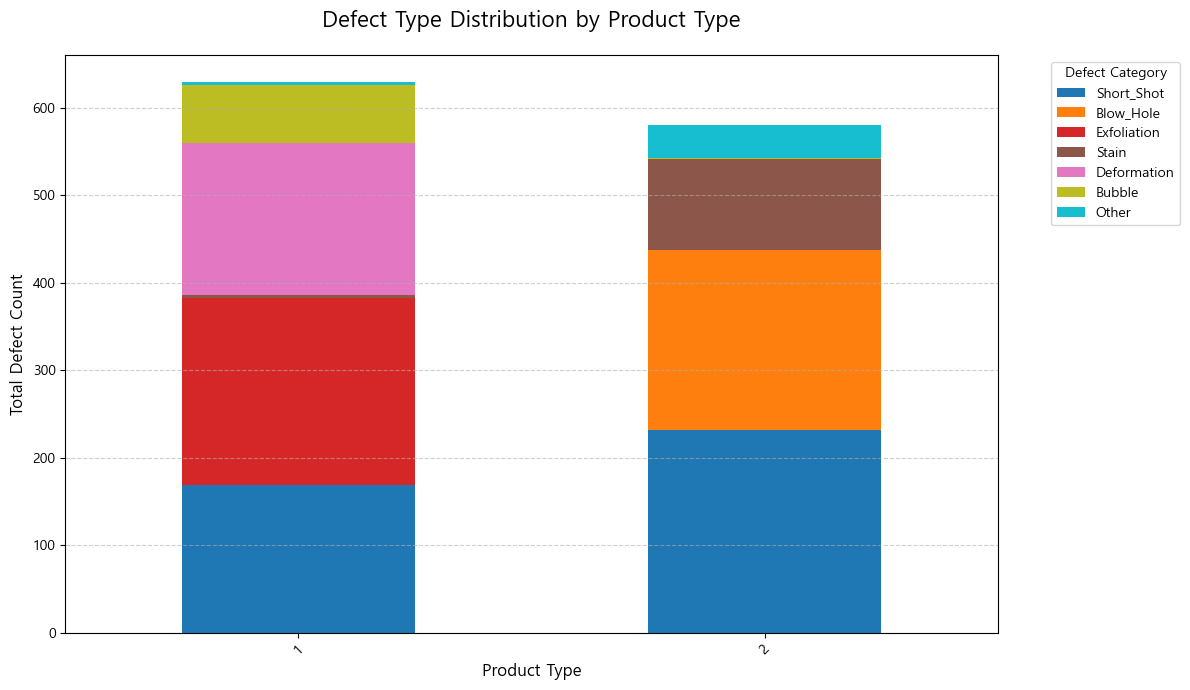

In [332]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. 데이터 집계: 딕셔너리를 순회하며 각 카테고리별 합계 컬럼 생성
# (각 세부 컬럼의 값이 0 또는 1이라고 가정할 때, 합산하면 해당 카테고리 발생 횟수가 됩니다)
agg_cols = []
for category, cols in defect_types.items():
    # 데이터프레임에 존재하는 컬럼들만 선택하여 합산
    valid_cols = [c for c in cols if c in df.columns]
    if valid_cols:
        df[category] = df[valid_cols].sum(axis=1)
        agg_cols.append(category)

# 2. product_type별로 그룹화하여 각 결함 카테고리의 합계 계산
df_plot = df.groupby('Product_Type')[agg_cols].sum()

# 3. 그래프 그리기 (누적 막대 그래프)
ax = df_plot.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab10')

# 그래프 디테일 설정
plt.title('Defect Type Distribution by Product Type', fontsize=16, pad=20)
plt.xlabel('Product Type', fontsize=12)
plt.ylabel('Total Defect Count', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Defect Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## STEP 6.타입 분리

In [ ]:
# ── Product_Type 1만 추출, type2도 동일하게 진행 
df1 = df[df['Product_Type'] == 1].reset_index(drop=True)
df2 = df[df['Product_Type'] == 2].reset_index(drop=True)


print(f"✅ Product_Type 1 추출 완료: {df1.shape[0]}행 × {df1.shape[1]}열")
print(f"✅ Product_Type 2 추출 완료: {df2.shape[0]}행 × {df2.shape[1]}열")

print(f"typ1추출 전체 대비: {df1.shape[0]}/4615행 ({df1.shape[0]/4615*100:.1f}%)")
print(f"typ2추출 전체 대비: {df2.shape[0]}/4615행 ({df2.shape[0]/4615*100:.1f}%)")

✅ Product_Type 1 추출 완료: 2651행 × 65열
✅ Product_Type 2 추출 완료: 1964행 × 65열
typ1추출 전체 대비: 2651/4615행 (57.4%)
typ2추출 전체 대비: 1964/4615행 (42.6%)


## STEP 4. 결측값 확인 및 처리

In [ ]:
missing1 = df1.isnull().sum()
missing1_cols = missing1[missing1 > 0]
if len(missing1_cols) == 0:
    print("결측값 없음")
else:
    print("결측값 보유 컬럼:")
    display(pd.DataFrame({'missing_count': missing1_cols,
                          'missing_ratio(%)': (missing_cols/len(df1)*100).round(2)}))

결측값 없음


In [ ]:
missing2 = df2.isnull().sum()
missing2_cols = missing2[missing2 > 0]
if len(missing2_cols) == 0:
    print("결측값 없음")
else:
    print("결측값 보유 컬럼:")
    display(pd.DataFrame({'missing_count': missing2_cols,
                          'missing_ratio(%)': (missing2_cols/len(df2)*100).round(2)}))

결측값 보유 컬럼:


,missing_count,missing_ratio(%)
Factory_Temp,45,2.29
Factory_Temp_Min,45,2.29
Factory_Temp_Max,45,2.29
Factory_Humidity,45,2.29
Factory_Humidity_Min,45,2.29
Factory_Humidity_Max,45,2.29
temp_diff,45,2.29
heat_index,45,2.29


In [ ]:
# Factory 센서 결측값 → 중앙값 대체 (Product_Type 1 단일이므로 전체 중앙값 사용)
missing_cols = [
    'Factory_Temp','Factory_Temp_Min','Factory_Temp_Max',
    'Factory_Humidity','Factory_Humidity_Min','Factory_Humidity_Max','temp_diff','heat_index'
]
for col in missing_cols:
    if df1[col].isnull().sum() > 0:
        df1[col] = df1[col].fillna(df1[col].median())

print(f"✅ 결측값 처리 완료 → 잔여 결측값: {df1.isnull().sum().sum()}건")

✅ 결측값 처리 완료 → 잔여 결측값: 0건


In [ ]:
for col in missing_cols:
    if df2[col].isnull().sum() > 0:
        df2[col] = df2[col].fillna(df2[col].median())

print(f"✅ 결측값 처리 완료 → 잔여 결측값: {df2.isnull().sum().sum()}건")

✅ 결측값 처리 완료 → 잔여 결측값: 0건


In [ ]:
df1.columns  

Index(['id', 'Product_Type', 'Shot', 'Velocity_1', 'Velocity_2', 'Velocity_3',
       'High_Velocity', 'Cylinder_Pressure', 'Rapid_Rise_Time',
       'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time',
       'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time', 'Spray_1_Time',
       'Spray_2_Time', 'Melting_Furnace_Temp', 'Air_Pressure',
       'Air_Pressure_Min', 'Air_Pressure_Max', 'Coolant_Temp',
       'Coolant_Temp_Min', 'Coolant_Temp_Max', 'Coolant_Pressure',
       'Factory_Temp', 'Factory_Temp_Min', 'Factory_Temp_Max',
       'Factory_Humidity', 'Factory_Humidity_Min', 'Factory_Humidity_Max',
       'Short_Shot_1', 'Bubble_1', 'Exfoliation_1', 'Blow_Hole_1', 'Stain_1',
       'Dent_1', 'Deformation_1', 'Contamination_1', 'Impurity_1', 'Crack_1',
       'Scratch_1', 'Buring_Mark_1', 'Inclusions_1', 'Short_Shot_2',
       'Bubble_2', 'Exfoliation_2', 'Blow_Hole_2', 'Stain_2', 'Dent_2',
       'Deformation_2', 'Contamination_2', 'Impurity_2', 'Crack_2',
       'Scratch_2', 'B

In [ ]:
exclude = {c for cols in defect_types.values() for c in cols}

df1 = df1.drop(columns=[col for col in df1.columns if col in exclude])
df2 = df2.drop(columns=[col for col in df2.columns if col in exclude])

In [ ]:
df1.dtypes

id                        int64
Product_Type              int64
Shot                      int64
Velocity_1              float64
Velocity_2              float64
Velocity_3              float64
High_Velocity           float64
Cylinder_Pressure         int64
Rapid_Rise_Time         float64
Biscuit_Thickness         int64
Clamping_Force            int64
Cycle_Time              float64
Pressure_Rise_Time      float64
Casting_Pressure          int64
Spray_Time              float64
Spray_1_Time            float64
Spray_2_Time            float64
Melting_Furnace_Temp    float64
Air_Pressure            float64
Air_Pressure_Min          int64
Air_Pressure_Max          int64
Coolant_Temp            float64
Coolant_Temp_Min          int64
Coolant_Temp_Max          int64
Coolant_Pressure        float64
Factory_Temp            float64
Factory_Temp_Min        float64
Factory_Temp_Max        float64
Factory_Humidity        float64
Factory_Humidity_Min    float64
Factory_Humidity_Max    float64
Defect_S

In [ ]:
from scipy import stats

exclude_cols = {'id', 'Product_Type', 'Shot', 'Defect_Status', 'Defect_Type'}
defect_cols = set()
for cols in defect_types.values():
    defect_cols.update(cols)

target_cols = [c for c in df1.columns if c not in exclude_cols and c not in defect_cols]

def get_spearman_rows(df, cols):
    rows = {}
    for col in cols:
        if col not in df.columns:
            continue
        valid = df[[col, 'Defect_Status']].dropna()
        if len(valid) < 2:
            continue
        rho, p = stats.spearmanr(valid[col], valid['Defect_Status'])
        rows[col] = (rho, p)
    return rows

r1 = get_spearman_rows(df1, target_cols)
r2 = get_spearman_rows(df2, target_cols)

print(f"\n{'변수명':<25} {'타입1 rho':>10}  {'유의':>4}    {'타입2 rho':>10}  {'유의':>4}")
print("=" * 65)

for col in target_cols:
    rho1, p1 = r1.get(col, (float('nan'), 1))
    rho2, p2 = r2.get(col, (float('nan'), 1))
    s1 = '✅' if p1 < 0.05 else '❌'
    s2 = '✅' if p2 < 0.05 else '❌'
    print(f"  {col:<23} {rho1:>+10.4f}  {s1}      {rho2:>+10.4f}  {s2}")


변수명                          타입1 rho    유의       타입2 rho    유의
  Velocity_1                 +0.0238  ❌         -0.0332  ❌
  Velocity_2                 -0.0409  ✅         +0.0750  ✅
  Velocity_3                 -0.0272  ❌         -0.0906  ✅
  High_Velocity              +0.0724  ✅         -0.2333  ✅
  Cylinder_Pressure          -0.1207  ✅         +0.1288  ✅
  Rapid_Rise_Time            +0.0372  ❌         -0.0125  ❌
  Biscuit_Thickness          -0.1698  ✅         +0.0484  ✅
  Clamping_Force             +0.0797  ✅         +0.1657  ✅
  Cycle_Time                 -0.1204  ✅         +0.1198  ✅
  Pressure_Rise_Time         +0.0990  ✅         -0.1454  ✅
  Casting_Pressure           -0.1252  ✅         +0.1039  ✅
  Spray_Time                 -0.0963  ✅         +0.1654  ✅
  Spray_1_Time               +0.0485  ✅         -0.0054  ❌
  Spray_2_Time               +0.1669  ✅         -0.1881  ✅
  Melting_Furnace_Temp       -0.0770  ✅         -0.0834  ✅
  Air_Pressure               +0.0730  ✅         +0.

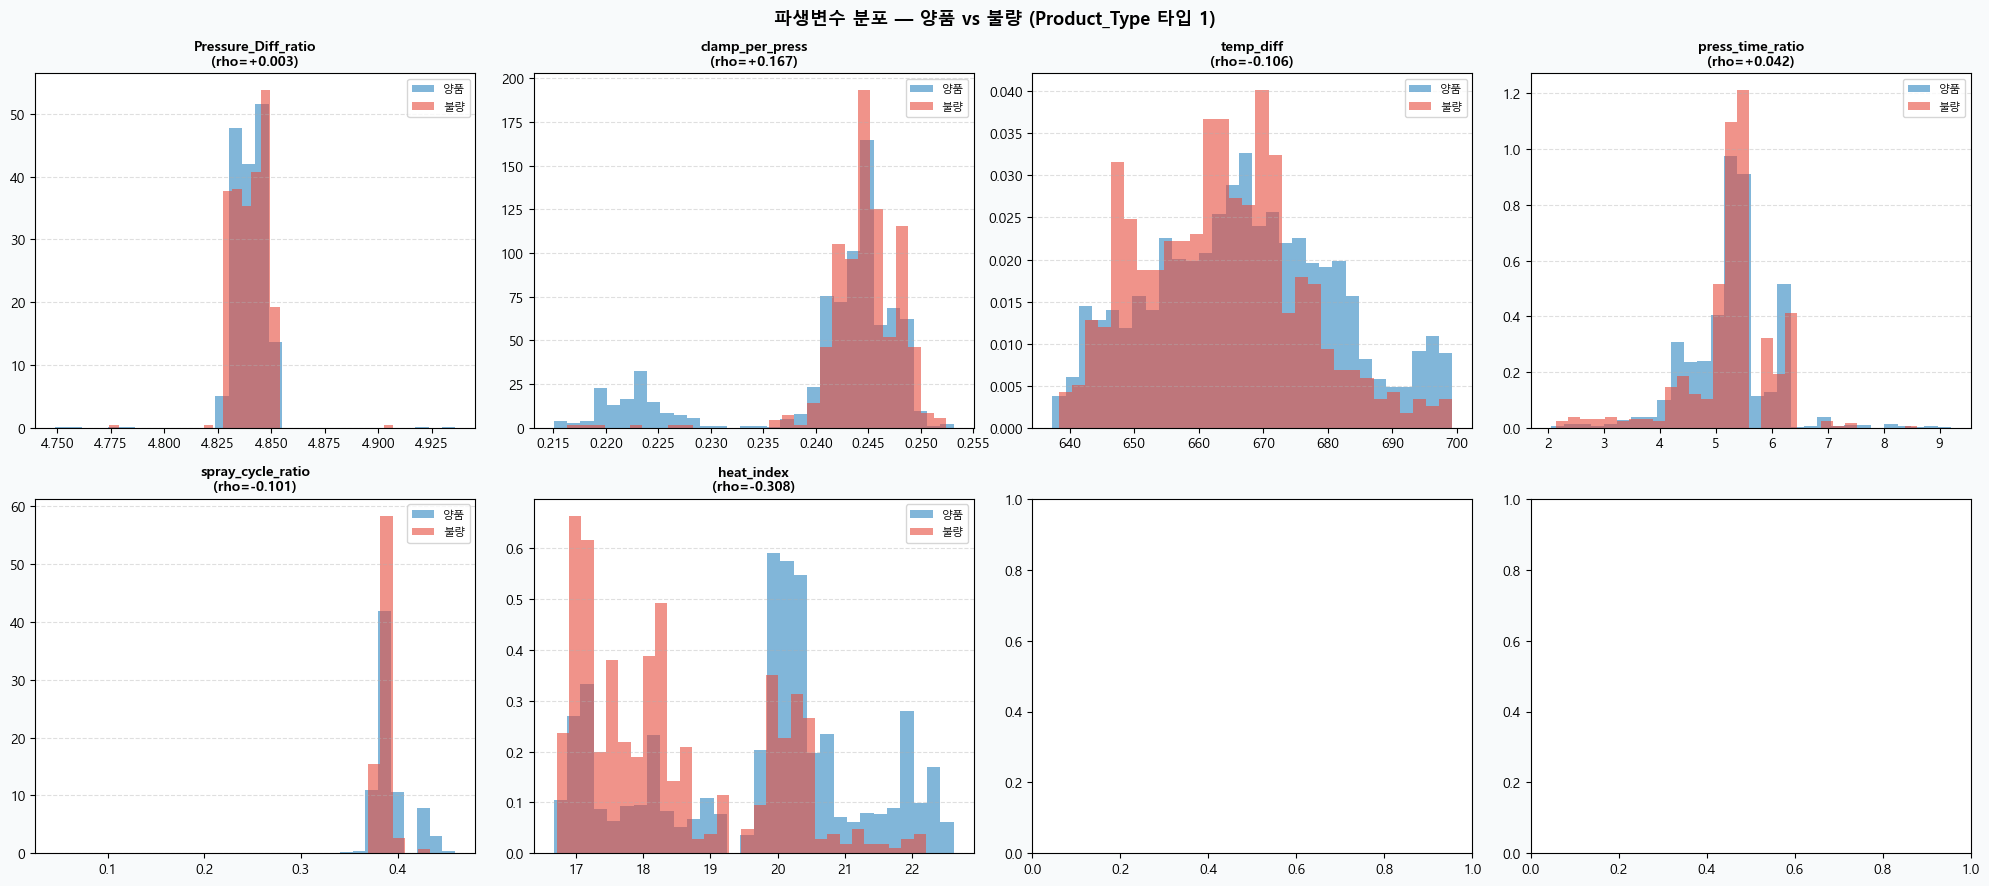

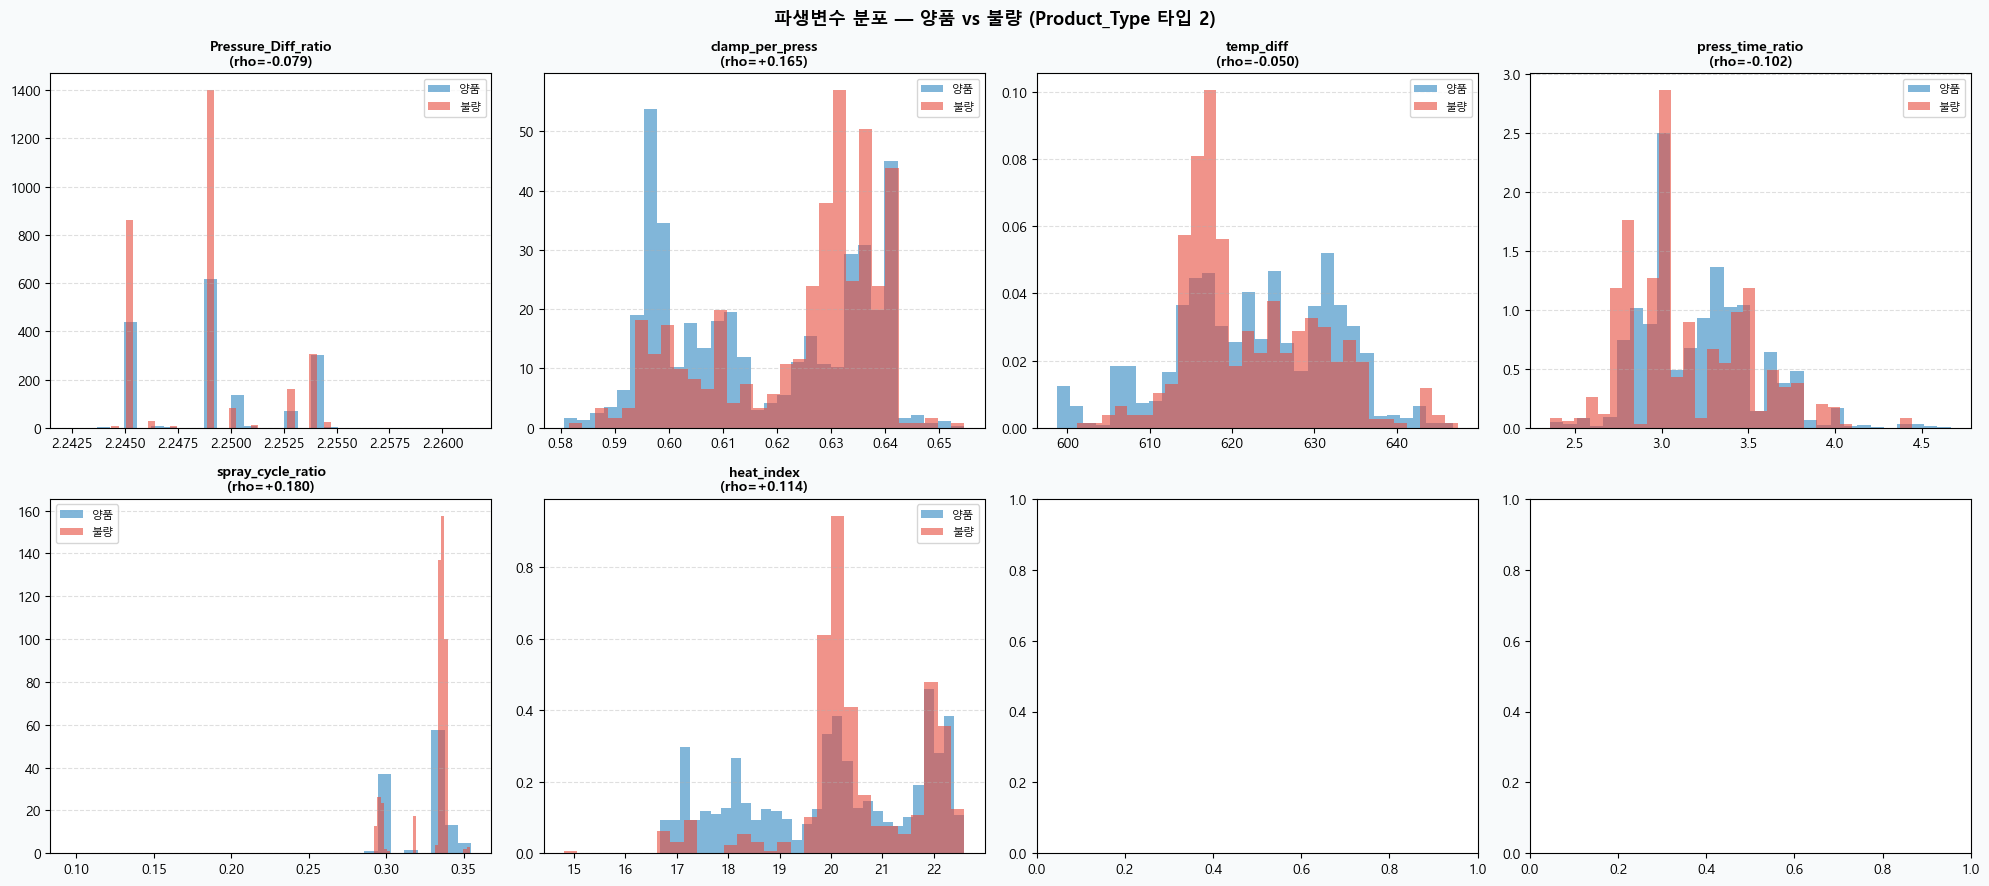

In [ ]:
for df, label in [(df1, '타입 1'), (df2, '타입 2')]:
    fig, axes = plt.subplots(2, 4, figsize=(20, 9), facecolor='#F8FAFB')
    axes = axes.flatten()

    colors = {'양품': '#2E86C1', '불량': '#E74C3C'}

    for i, col in enumerate(NEW_FEATURES):
        good = df[df['Defect_Status'] == 0][col].dropna()
        bad  = df[df['Defect_Status'] == 1][col].dropna()
        rho, _ = stats.spearmanr(df[col].dropna(), df.loc[df[col].notna(), 'Defect_Status'])

        axes[i].hist(good, bins=30, alpha=0.6, color=colors['양품'], label='양품', density=True)
        axes[i].hist(bad,  bins=30, alpha=0.6, color=colors['불량'], label='불량', density=True)
        axes[i].set_title(f'{col}\n(rho={rho:+.3f})', fontweight='bold', fontsize=10)
        axes[i].legend(fontsize=8)
        axes[i].grid(axis='y', linestyle='--', alpha=0.4)

    plt.suptitle(f'파생변수 분포 — 양품 vs 불량 (Product_Type {label})', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## STEP 7. 변수별 분포 시각화

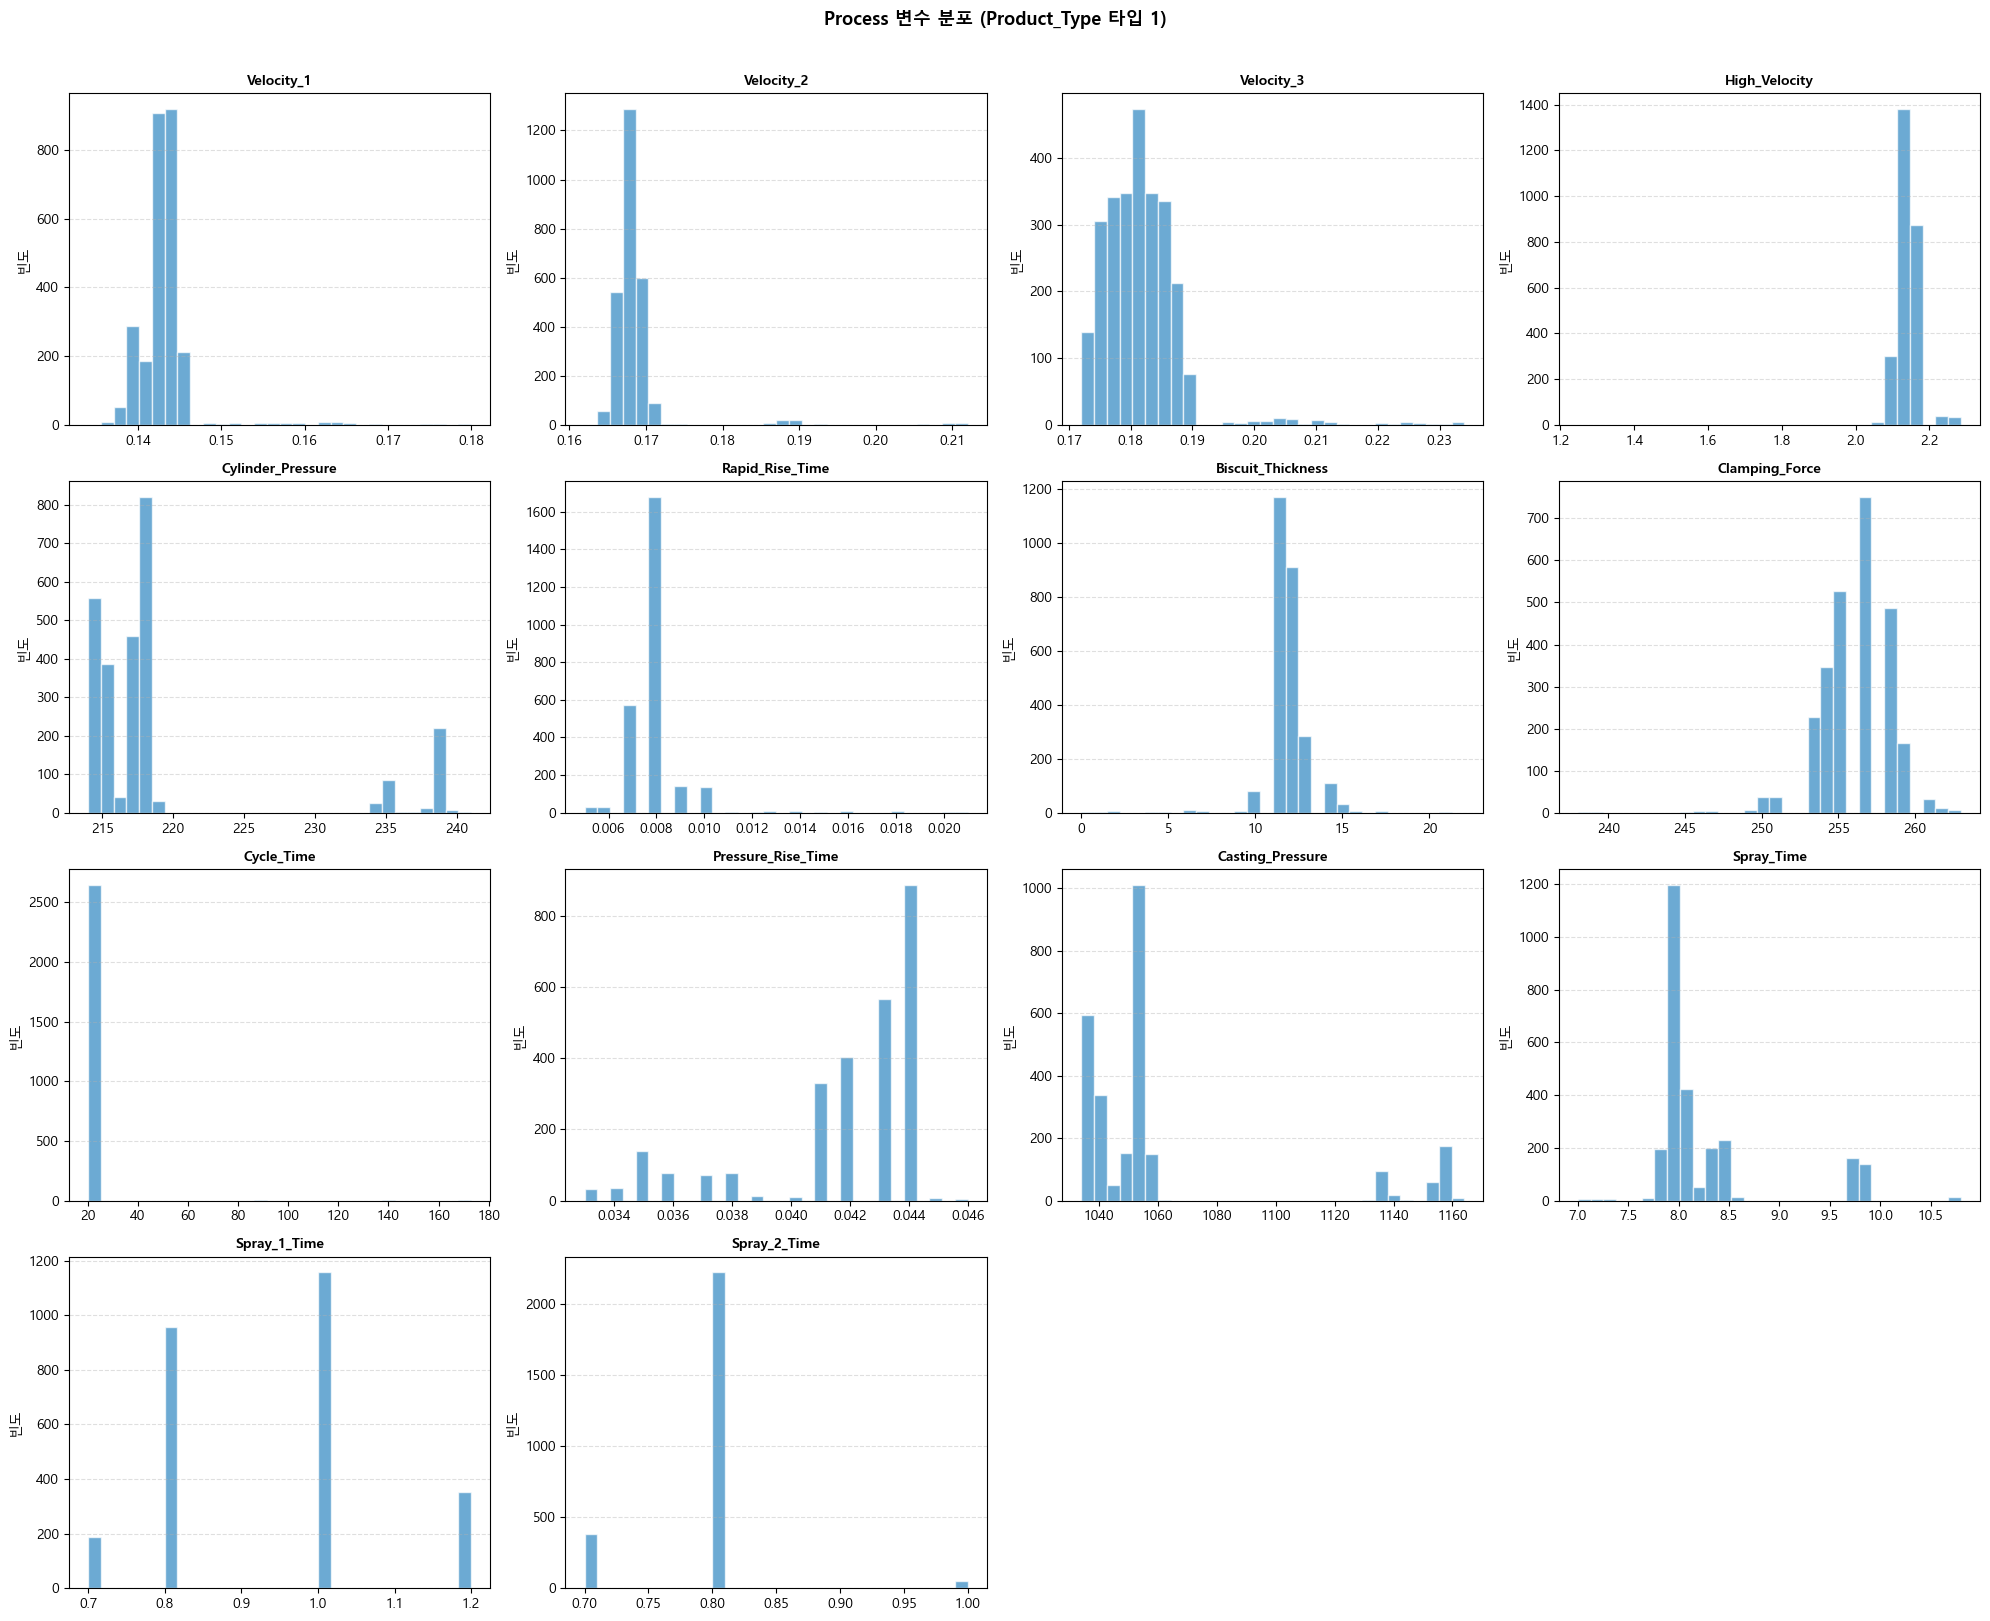

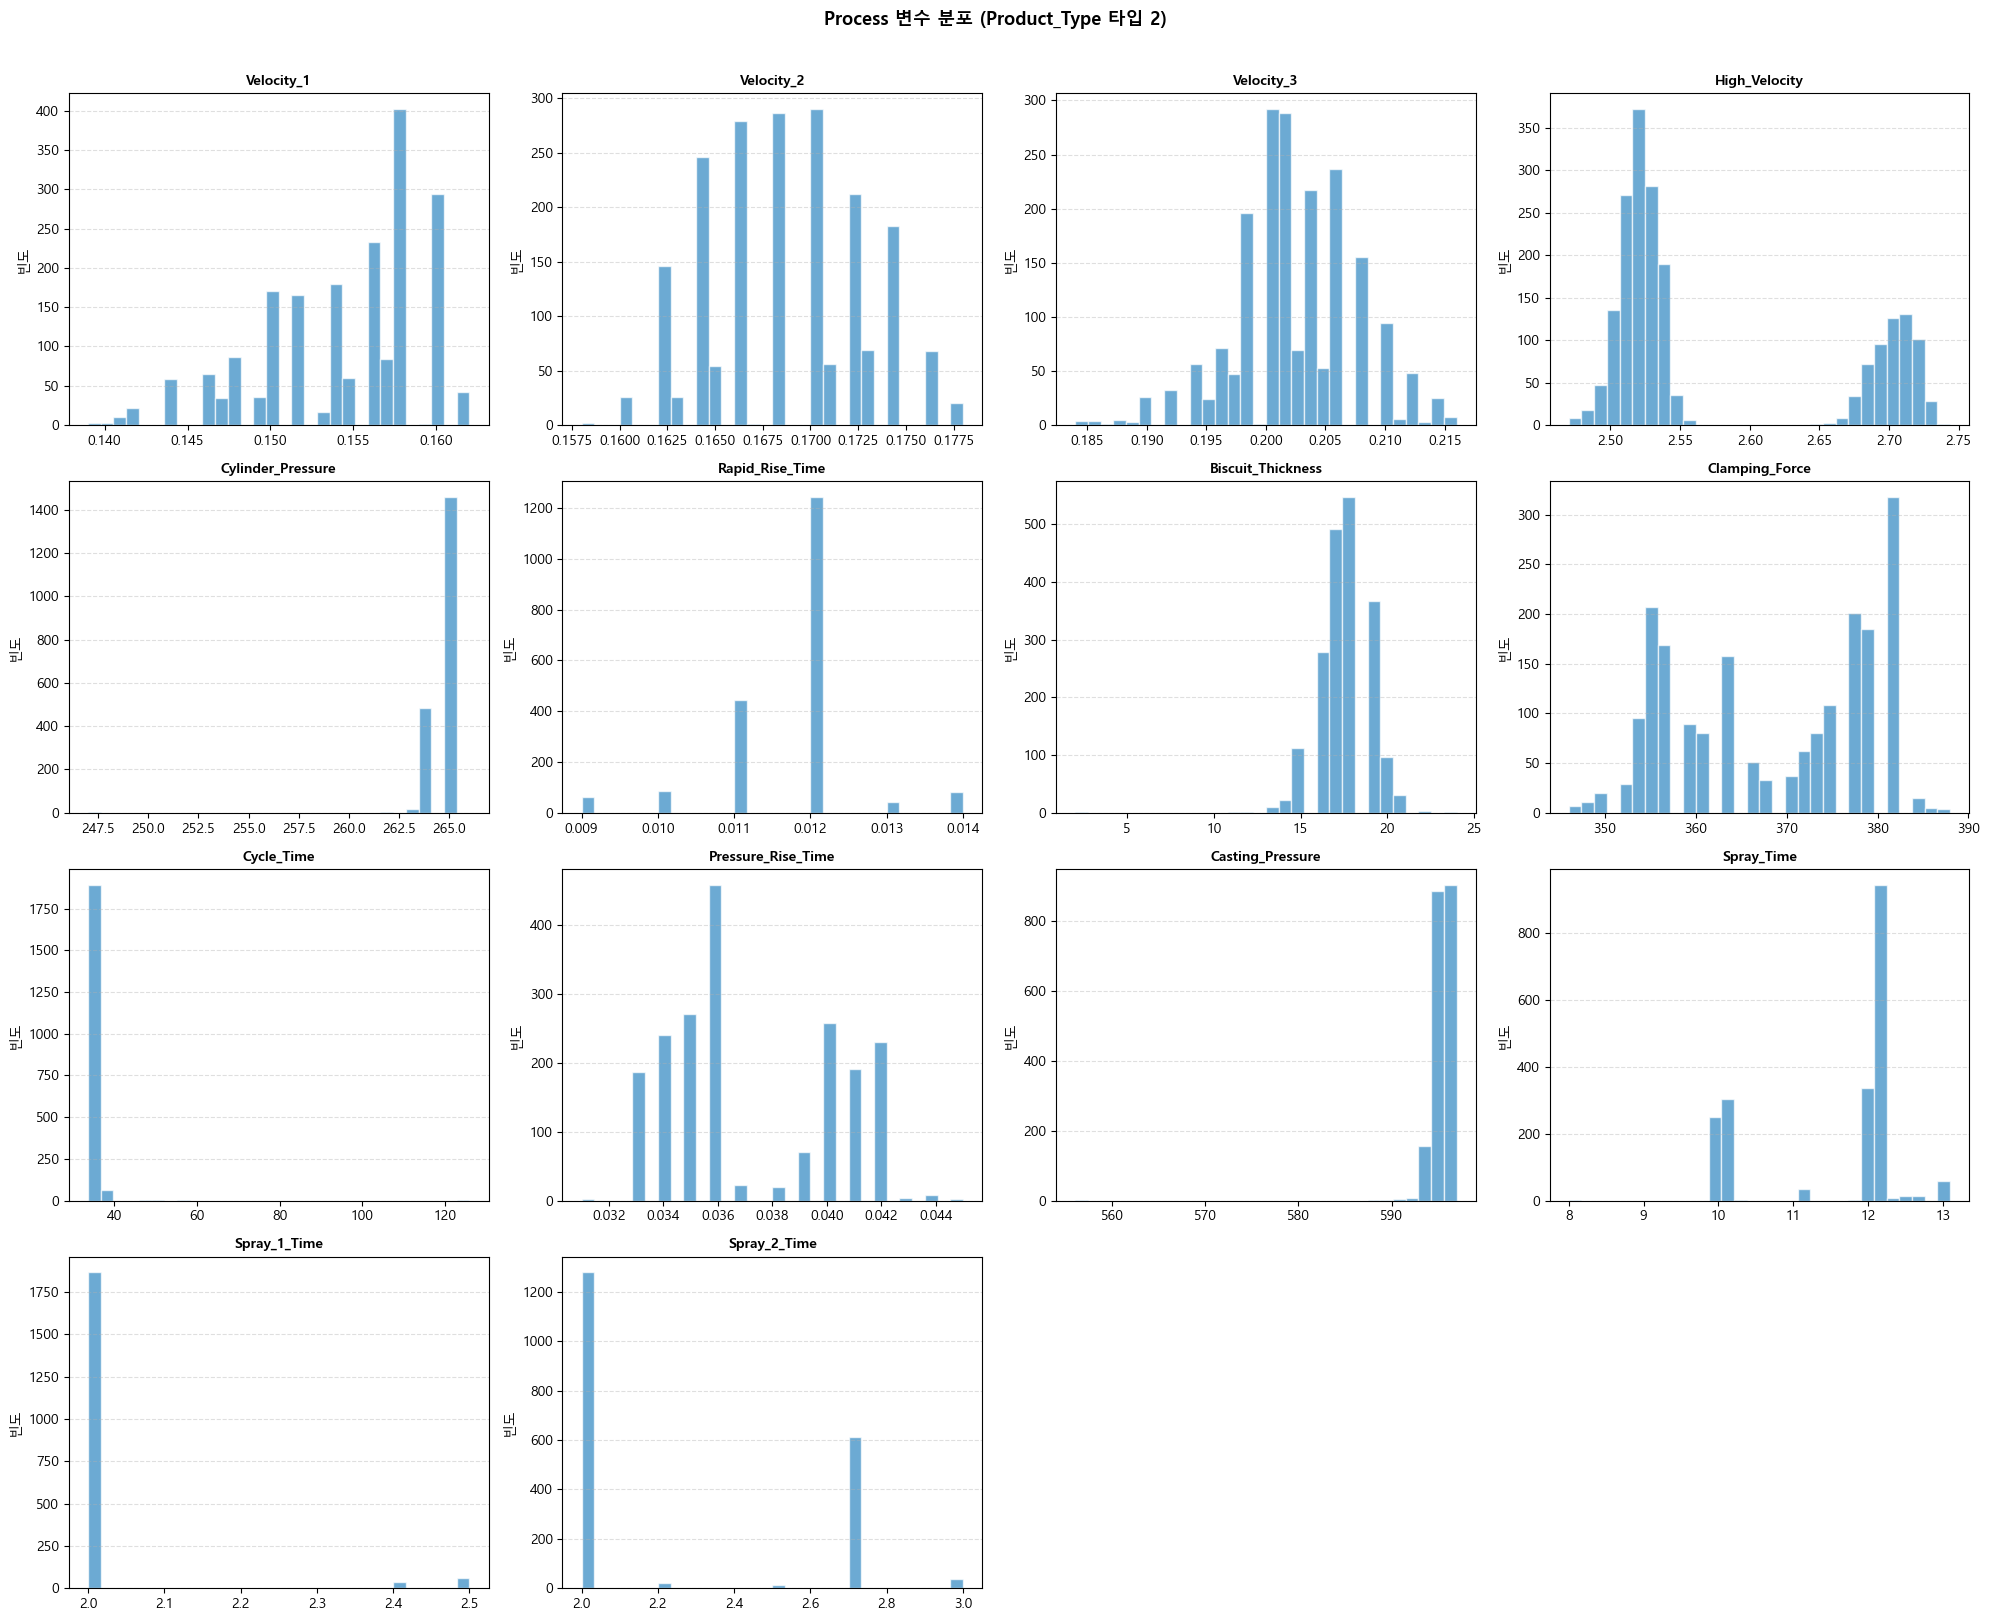

In [ ]:
for df, label in [(df1, '타입 1'), (df2, '타입 2')]:
    n_cols, n_rows = 4, (len(process_num_cols) + 3) // 4
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
    axes = axes.flatten()

    for i, col in enumerate(process_num_cols):
        axes[i].hist(df[col].dropna(), bins=30, color='#2E86C1', alpha=0.7, edgecolor='white')
        axes[i].set_title(col, fontsize=10, fontweight='bold')
        axes[i].set_ylabel('빈도')
        axes[i].grid(axis='y', linestyle='--', alpha=0.4)

    for j in range(i+1, len(axes)): axes[j].set_visible(False)
    plt.suptitle(f'Process 변수 분포 (Product_Type {label})', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

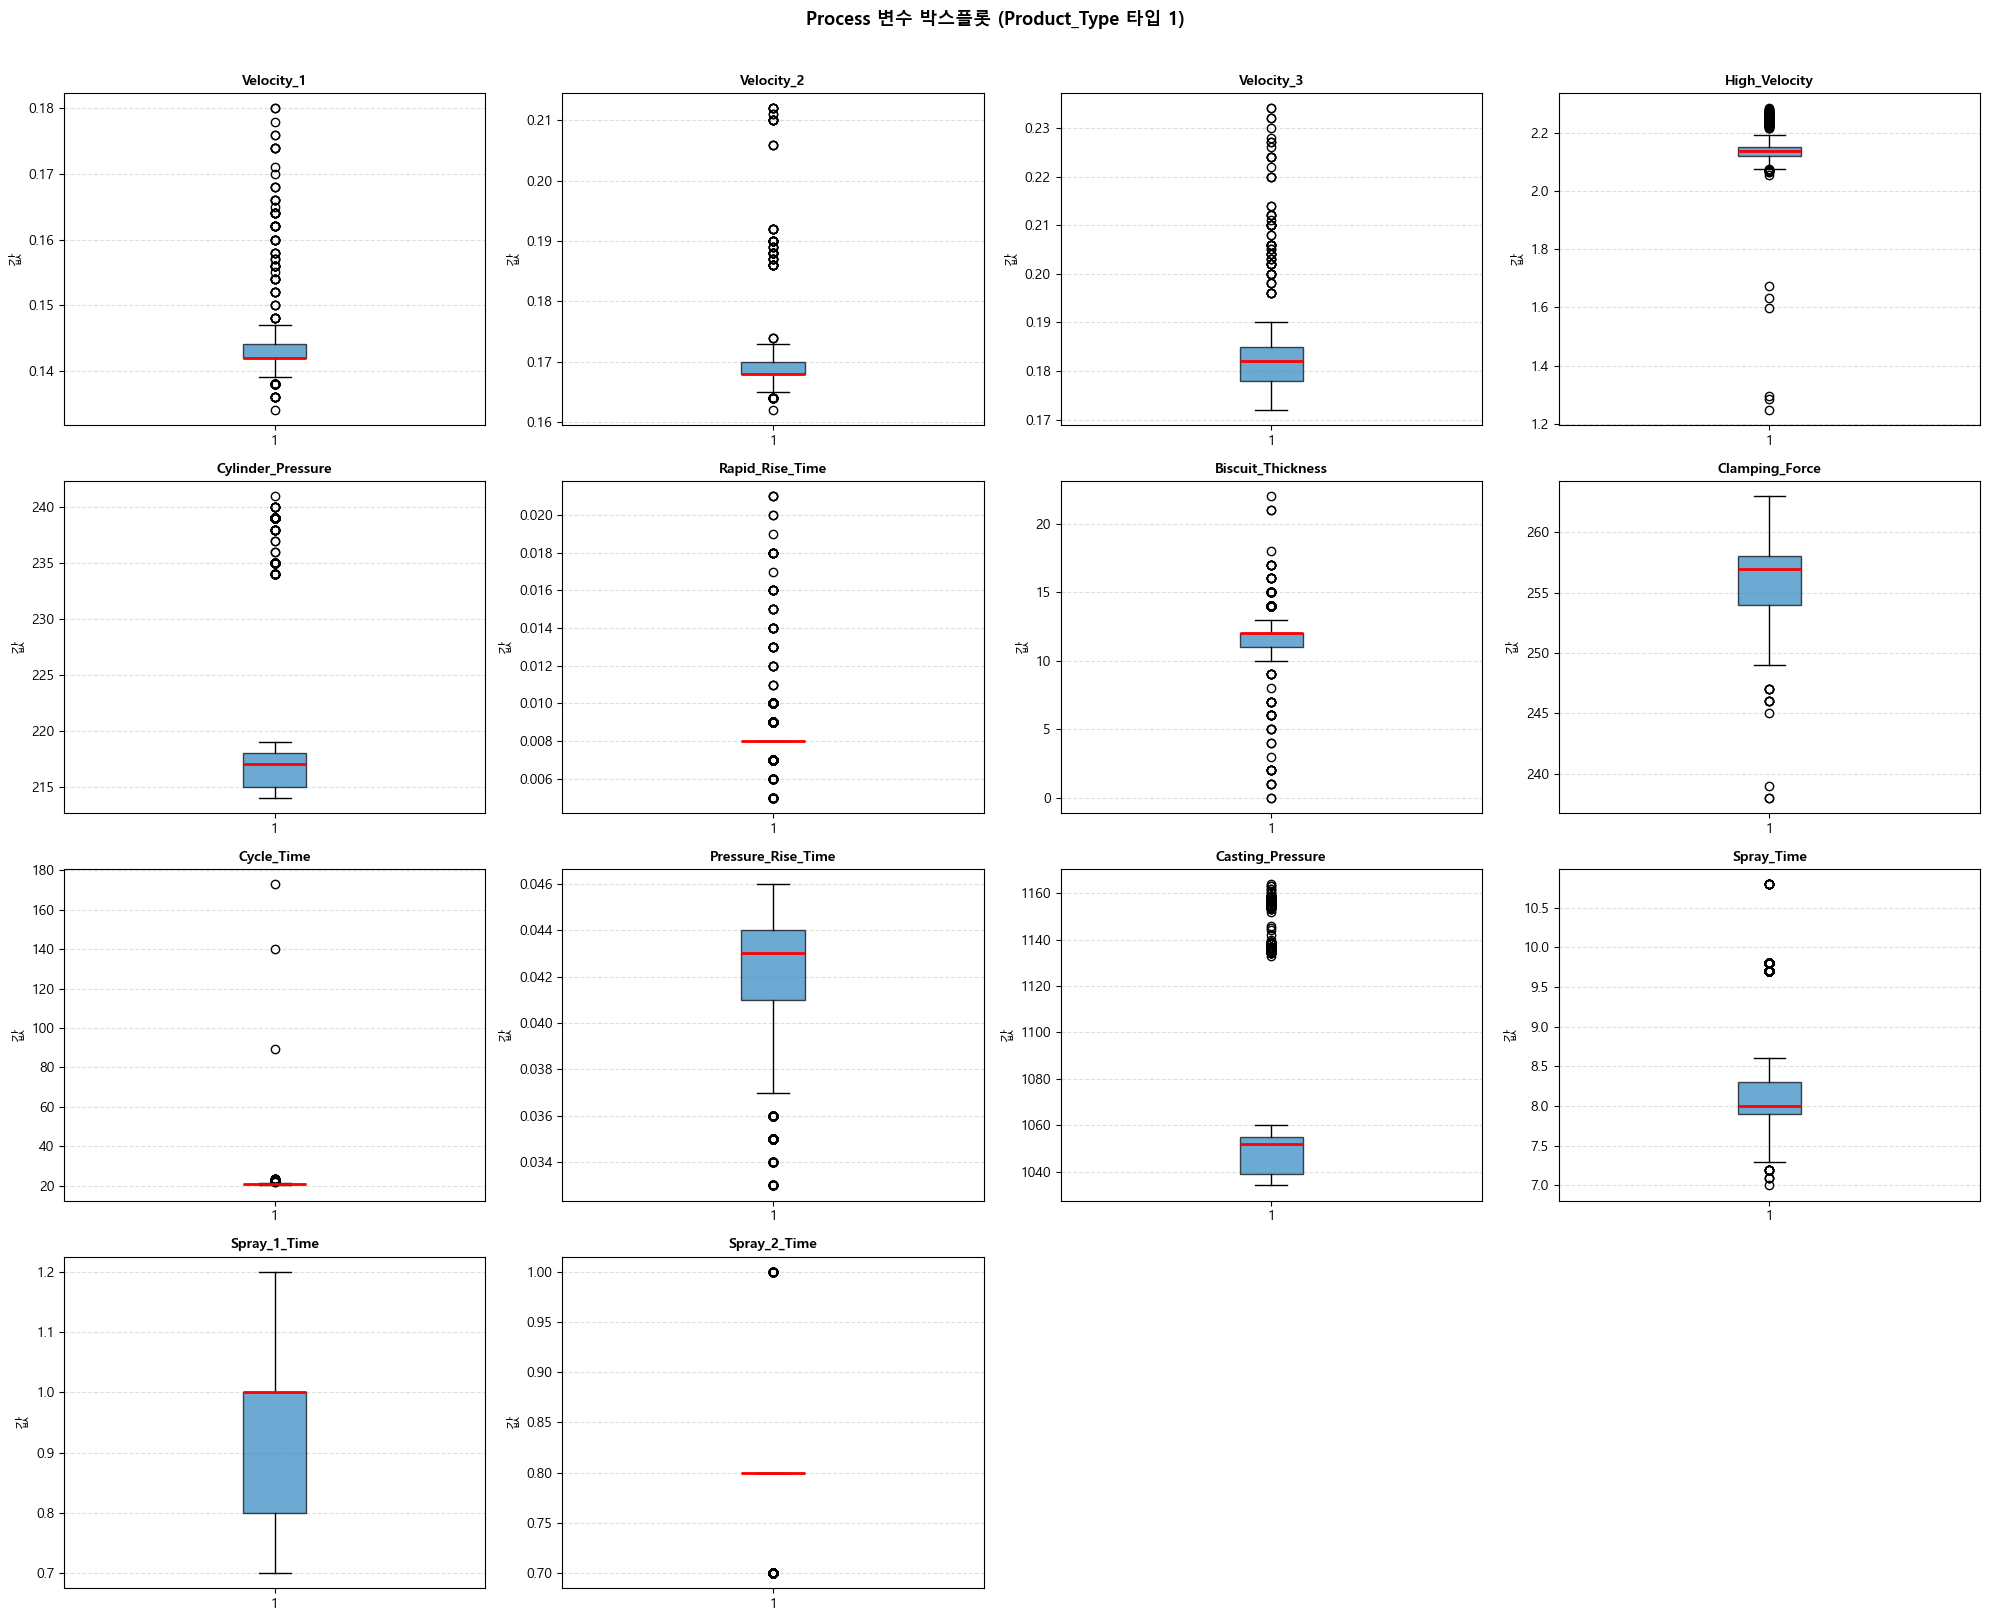

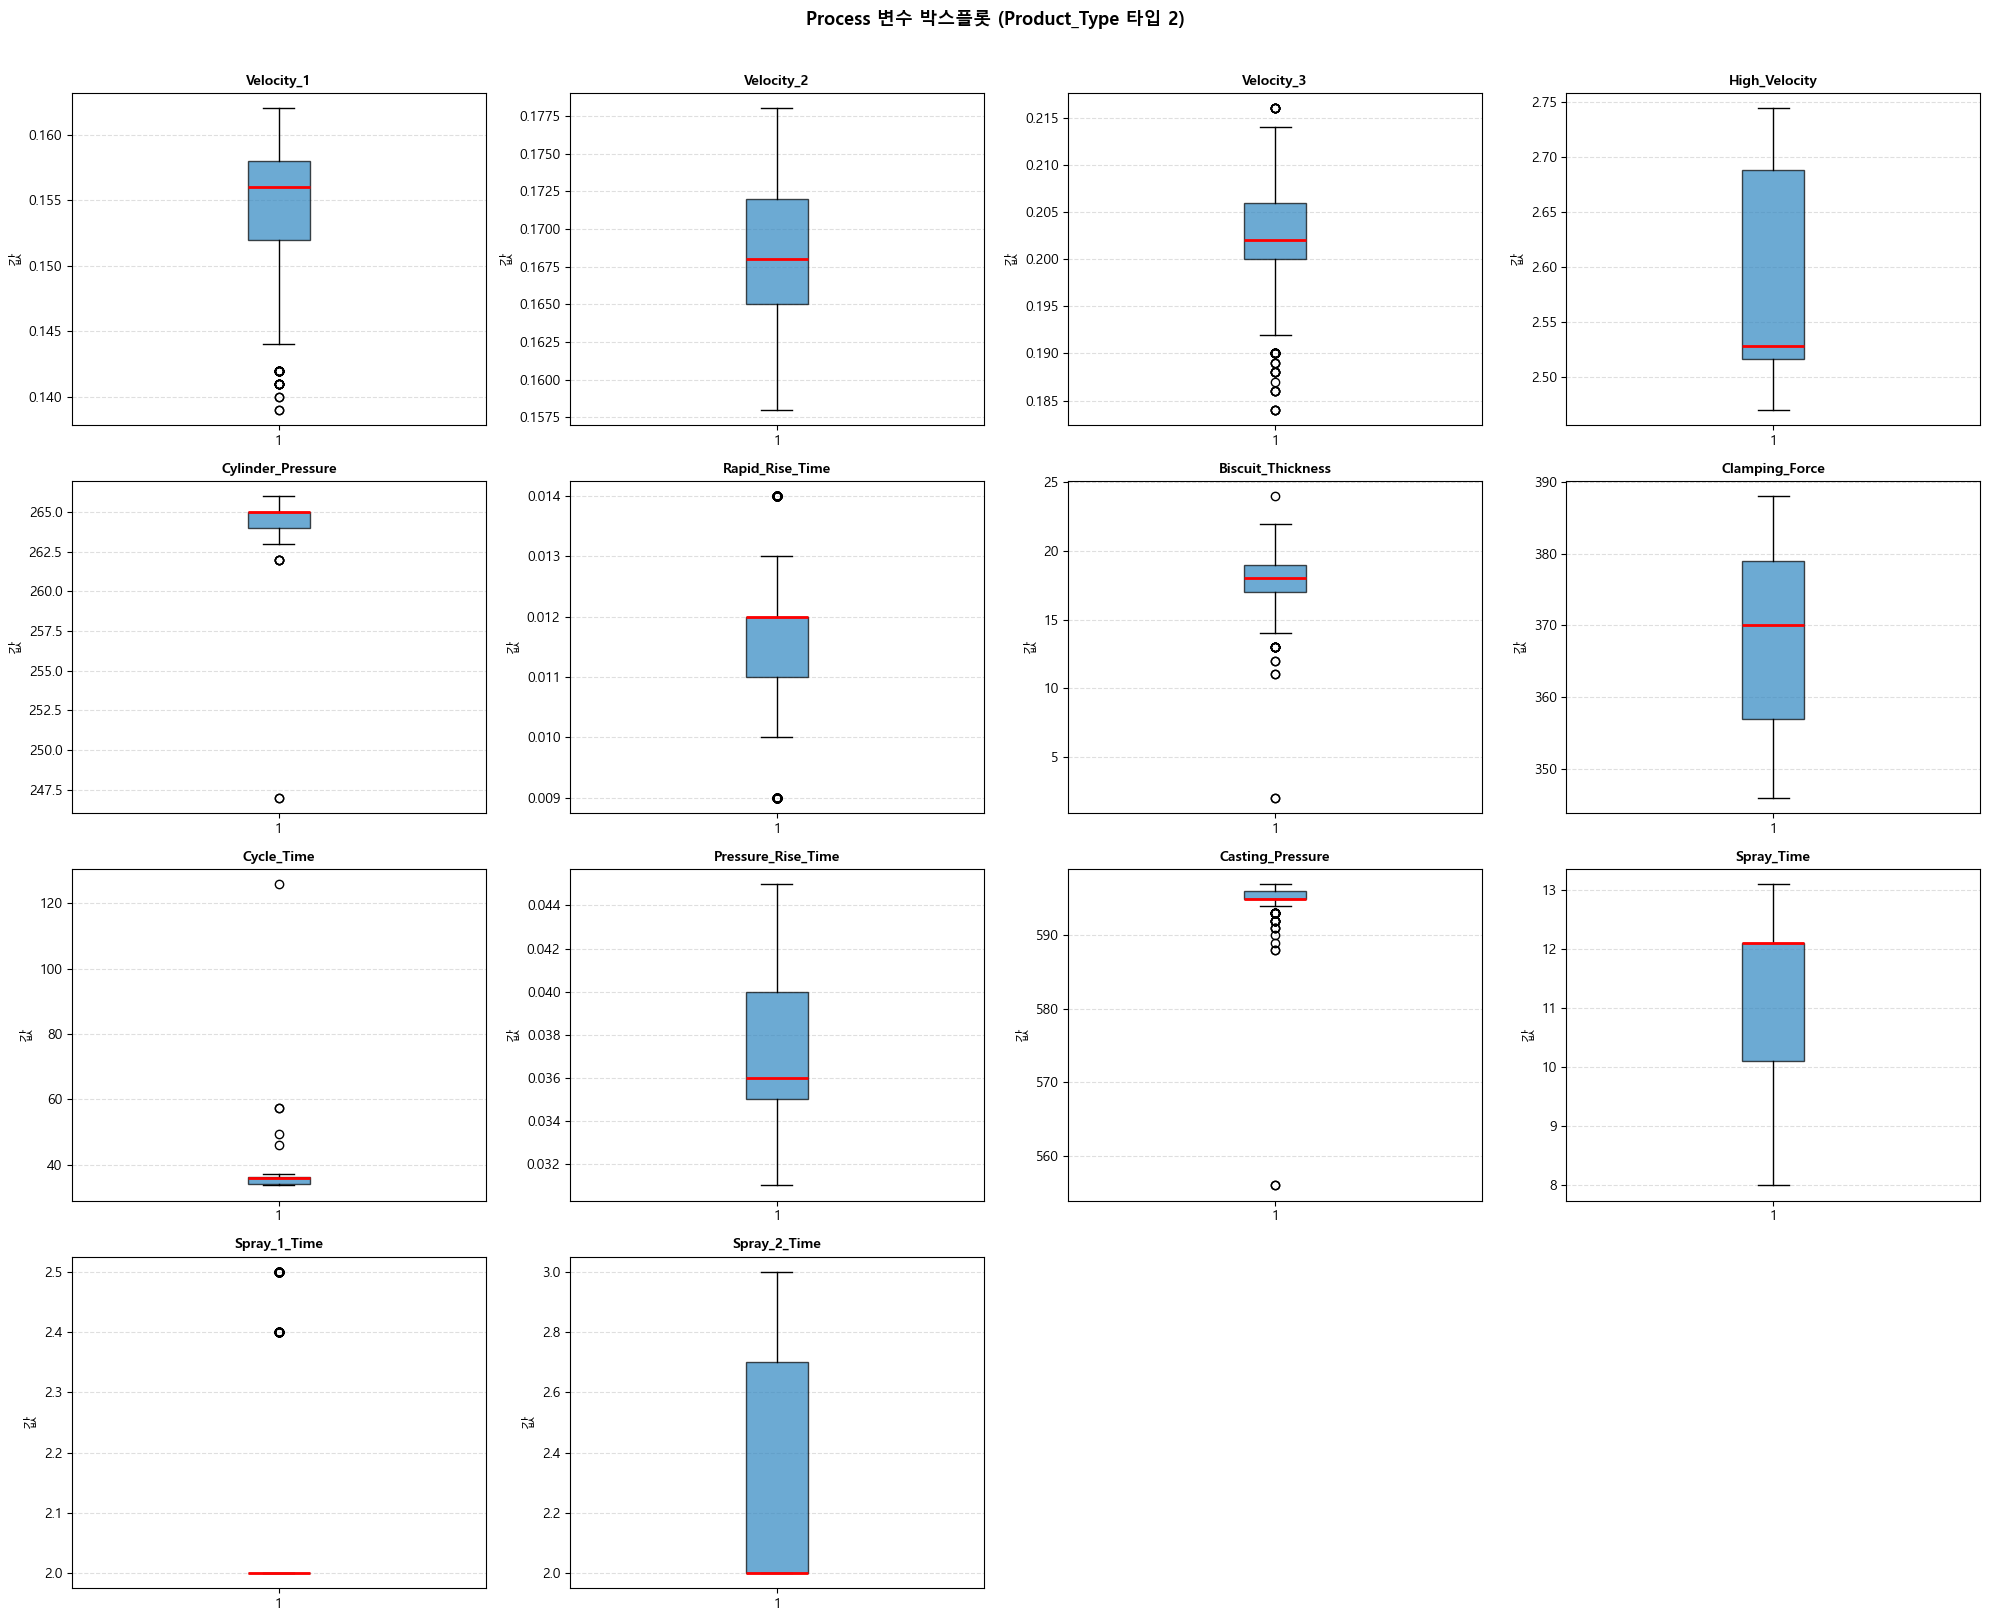

In [ ]:
for df, label in [(df1, '타입 1'), (df2, '타입 2')]:
    n_cols, n_rows = 4, (len(process_num_cols) + 3) // 4
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
    axes = axes.flatten()

    for i, col in enumerate(process_num_cols):
        axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                        boxprops=dict(facecolor='#2E86C1', alpha=0.7),
                        medianprops=dict(color='red', linewidth=2))
        axes[i].set_title(col, fontsize=10, fontweight='bold')
        axes[i].set_ylabel('값')
        axes[i].grid(axis='y', linestyle='--', alpha=0.4)

    for j in range(i+1, len(axes)): axes[j].set_visible(False)
    plt.suptitle(f'Process 변수 박스플롯 (Product_Type {label})', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

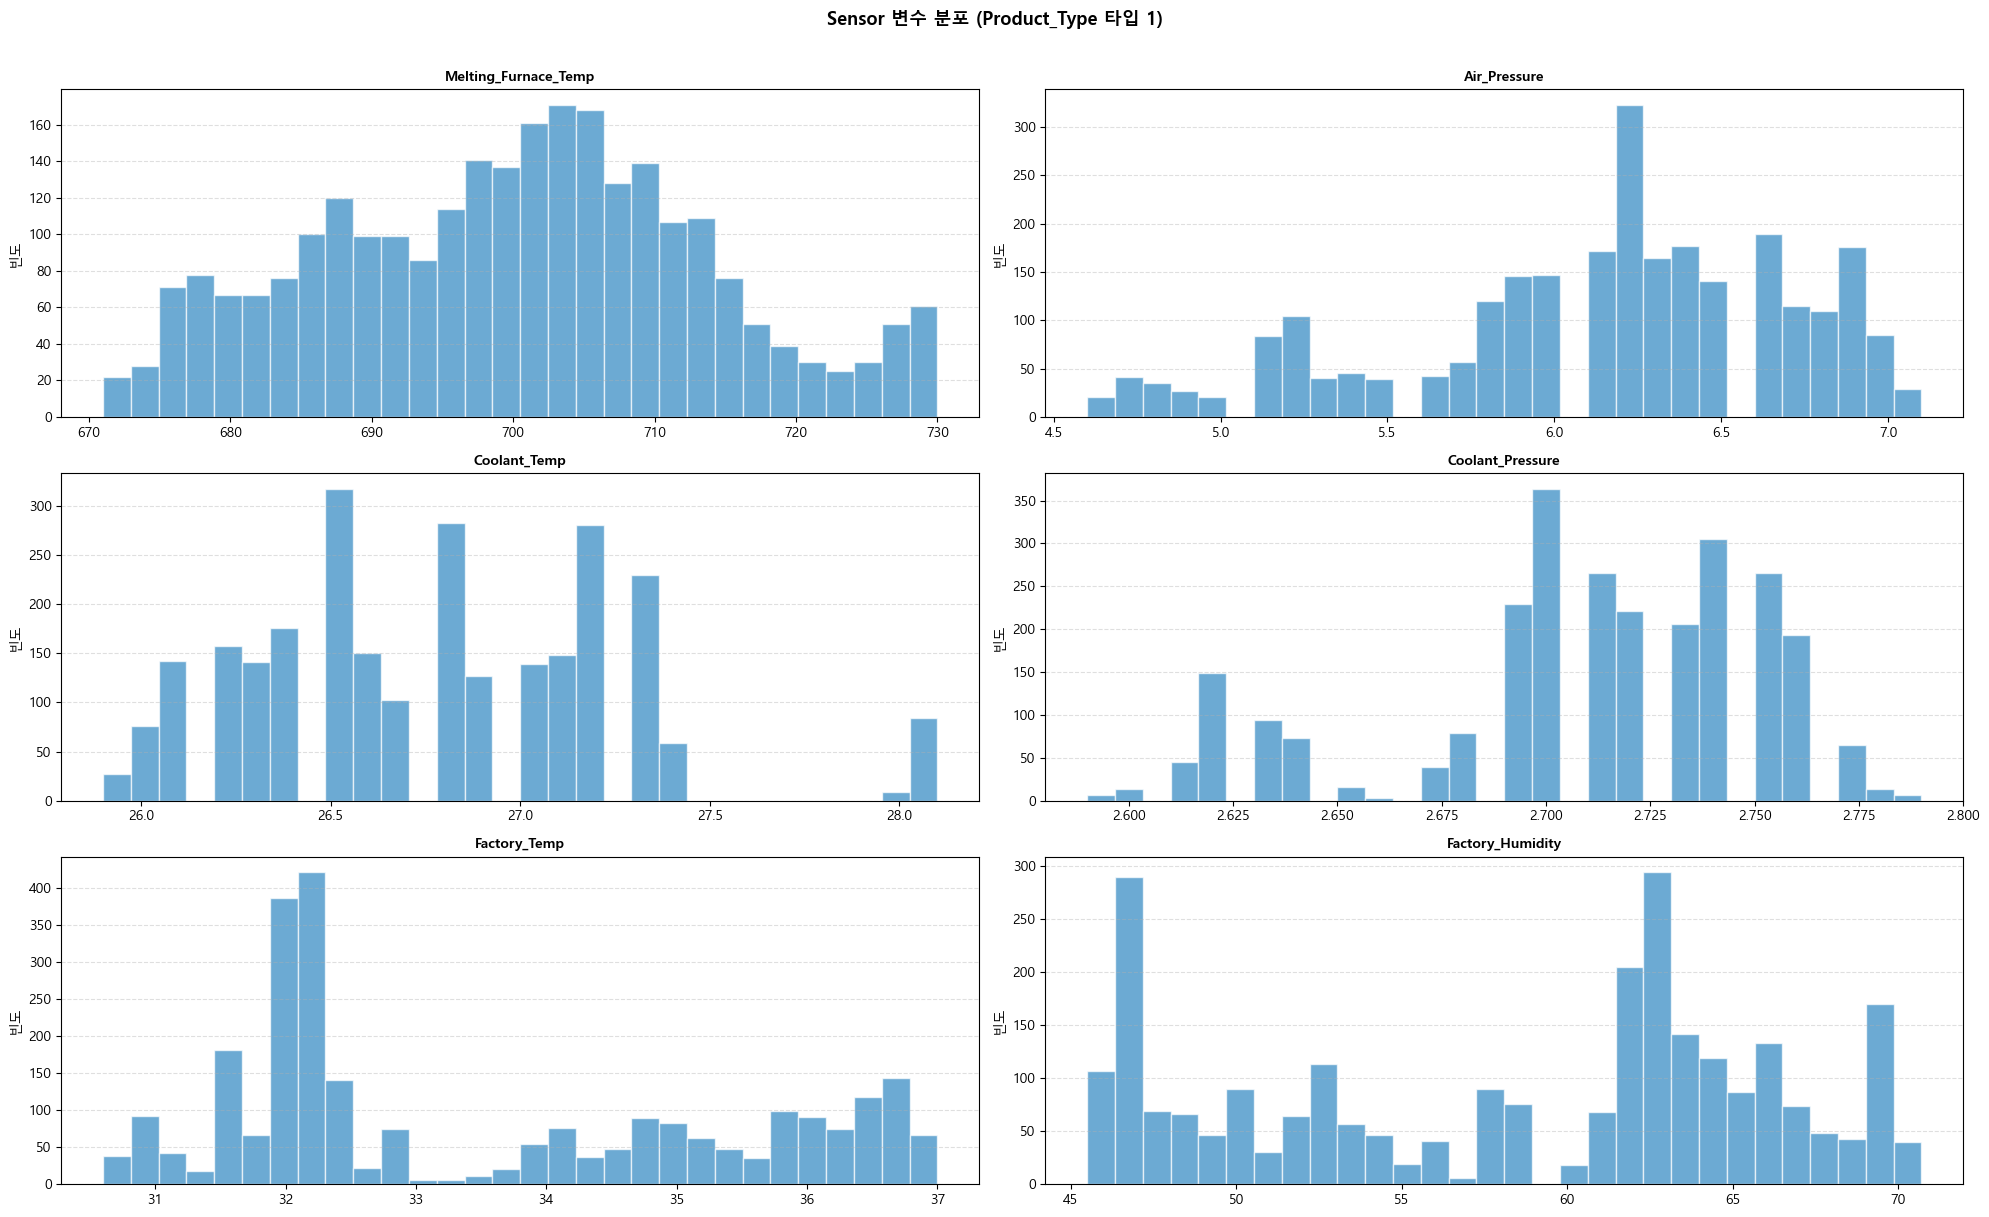

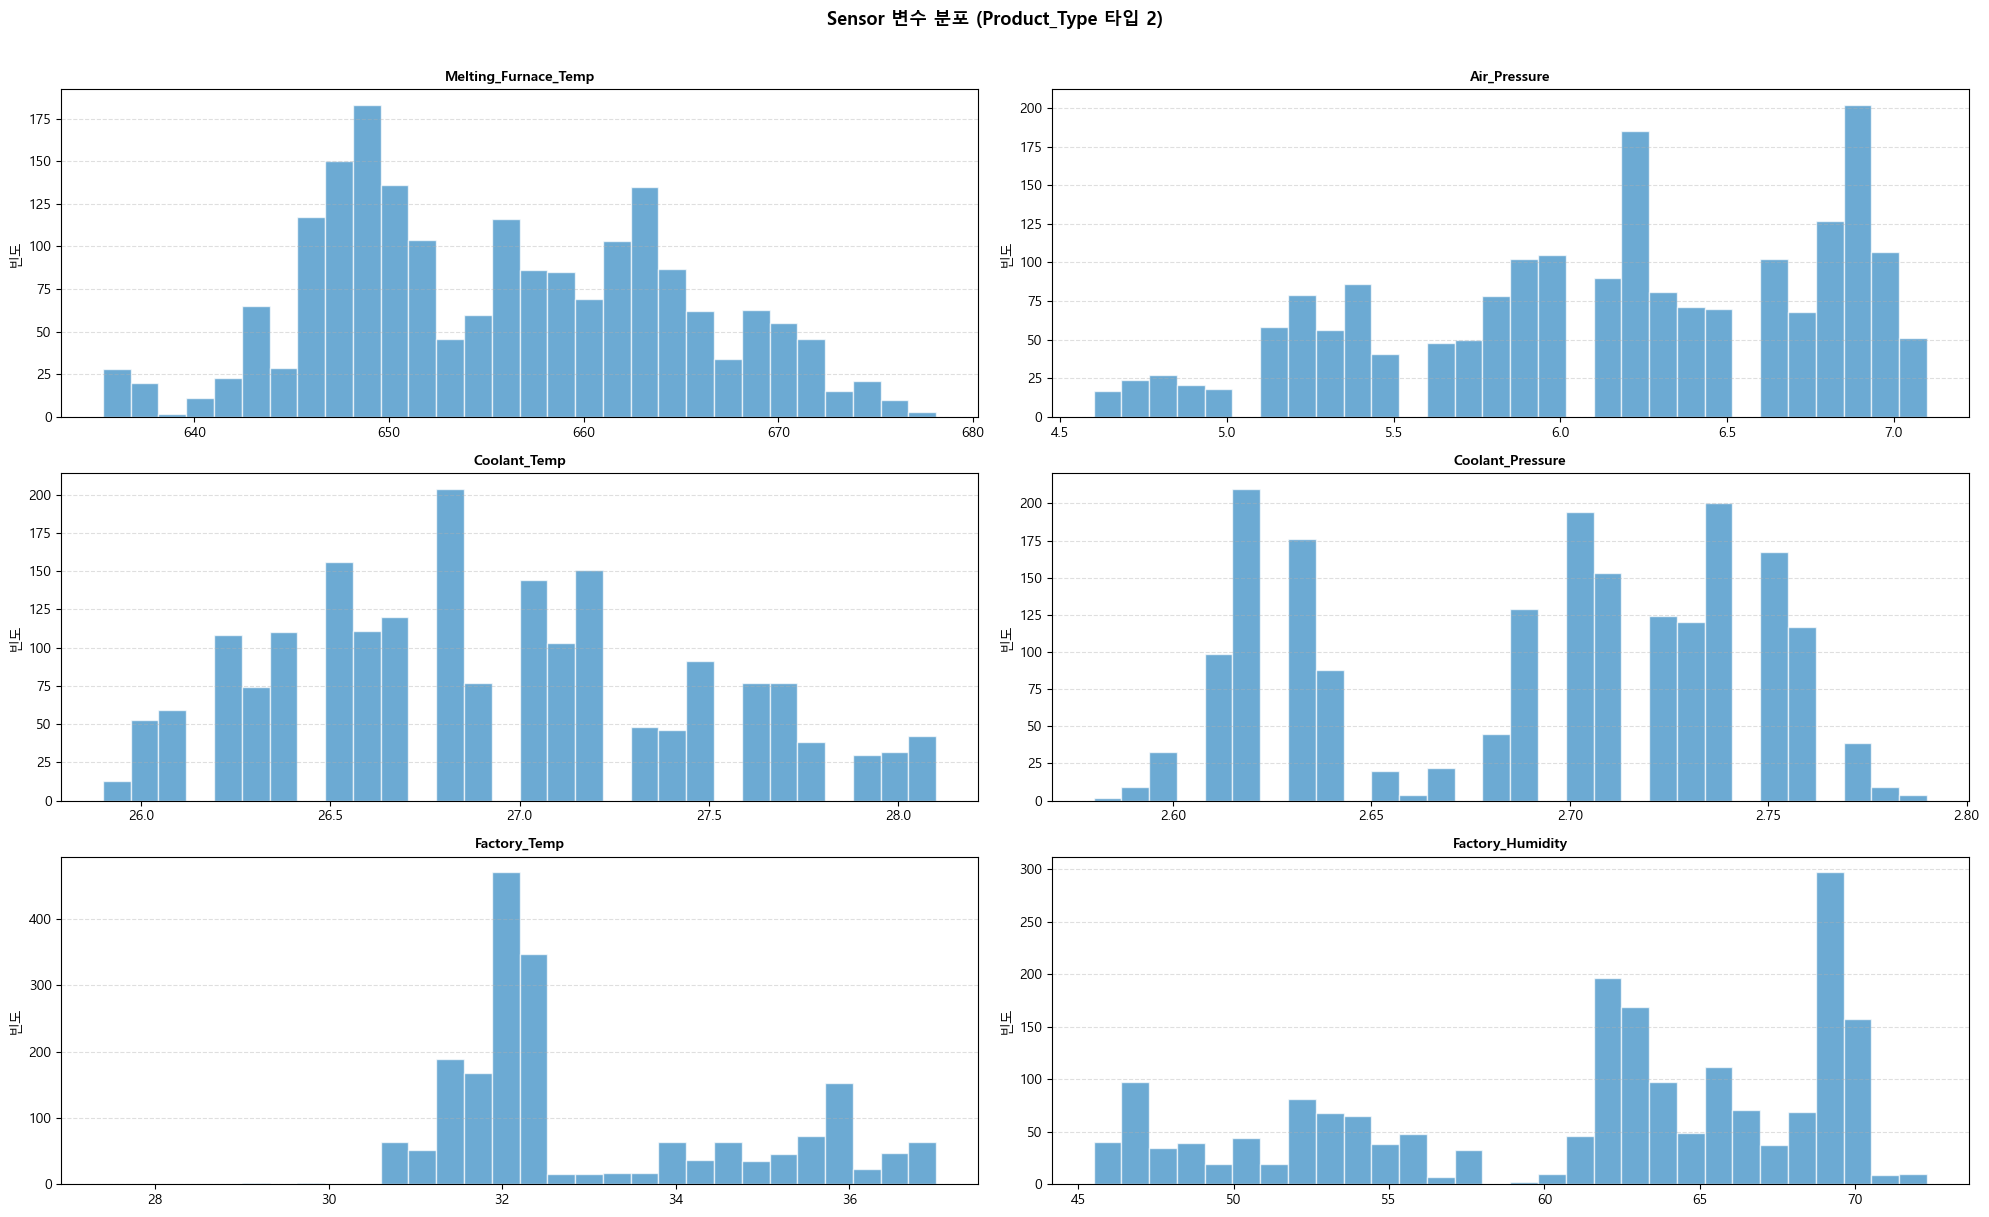

In [ ]:
sensor_num_cols = [
    'Melting_Furnace_Temp','Air_Pressure','Coolant_Temp','Coolant_Pressure',
    'Factory_Temp','Factory_Humidity'
]

for df, label in [(df1, '타입 1'), (df2, '타입 2')]:
    n_cols, n_rows = 2, 3
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
    axes = axes.flatten()

    for i, col in enumerate(sensor_num_cols):
        axes[i].hist(df[col].dropna(), bins=30, color='#2E86C1', alpha=0.7, edgecolor='white')
        axes[i].set_title(col, fontsize=10, fontweight='bold')
        axes[i].set_ylabel('빈도')
        axes[i].grid(axis='y', linestyle='--', alpha=0.4)

    for j in range(i+1, len(axes)): axes[j].set_visible(False)
    plt.suptitle(f'Sensor 변수 분포 (Product_Type {label})', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

## STEP 8. 전처리 완료 데이터 저장

In [ ]:
save_cols = (
    ['id', 'Product_Type', 'Shot']
    + process_num_cols
    + ['Melting_Furnace_Temp', 'Air_Pressure', 'Coolant_Temp',
       'Coolant_Pressure', 'Factory_Temp', 'Factory_Humidity']
    + NEW_FEATURES
    + ['Defect_Status', 'Defect_Type']
)

df1_with_features = df1[save_cols].copy()
df2_with_features = df2[save_cols].copy()
df1_with_features.to_csv('../../data/df_type1_final.csv', index=False)
df2_with_features.to_csv('../../data/df_type2_final.csv', index=False)

print(f"✅ 저장 완료: data/df_type1_final.csv")
print(f"   Shape: {df1_with_features.shape[0]}행 × {df1_with_features.shape[1]}열")
print(f"   원본({25}열) 대비 파생변수 {len(NEW_FEATURES)}개 추가")
print(f"\n[ 컬럼 목록 ]")

print(f"✅ 저장 완료: data/df_type2_final.csv")
print(f"   Shape: {df2_with_features.shape[0]}행 × {df2_with_features.shape[1]}열")
print(f"   원본({25}열) 대비 파생변수 {len(NEW_FEATURES)}개 추가")
print(f"\n[ 컬럼 목록 ]")

for i, col in enumerate(df1_with_features.columns, 1):
    marker = ' ← 신규' if col in NEW_FEATURES and col != 'Pressure_Diff_ratio' else ''
    print(f"  {i:2d}. {col}{marker}")
df1_with_features.head(3)

for i, col in enumerate(df2_with_features.columns, 1):
    marker = ' ← 신규' if col in NEW_FEATURES and col != 'Pressure_Diff_ratio' else ''
    print(f"  {i:2d}. {col}{marker}")
df2_with_features.head(3)


OSError: Cannot save file into a non-existent directory: '..\..\data'